Note: for good comparison, we should likely benchmark on the $z$ prediction (downstream model) both the vanilla version trained with a recon objective to recon $x$, and the one here trained to recon $x_{t+1}$.


Small window size=1 for backbone cause weird representations. Sizes like w=10 are better to get a clear continuation. So maybe for the latent forecast we need a larger window.

In [1]:
import lindi

url = 'https://api.dandiarchive.org/api/assets/1e11c74e-6f25-4604-9216-5b861fec8f1c/download/'

# Load the remote file
f = lindi.LindiH5pyFile.from_hdf5_file(url)

# Load the neurodata object (TimeSeries)
NeuralTrace = f['/processing/ophys/NeuralTrace']
neural = NeuralTrace['data'][:]
rate = 10 # 10 Hz

In [2]:
import jax.numpy as jnp

print(f"shape of neural activity: {neural.shape}")
n_timesteps, n_neurons = neural.shape
t_max = n_timesteps / rate
t_grid = jnp.linspace(0, t_max, n_timesteps)
dt = 1. / rate # seconds per bin
n_trials = 1

print(f"trial duration: {t_max}")
print(f"seconds per bin: {dt}")

shape of neural activity: (4201, 56)
trial duration: 420.1
seconds per bin: 0.1


z-score activity of each neuron like SING did

In [3]:
# Normalize data
norm_neural = (neural - neural.mean(0)) / neural.std(0)

## EDA

In [4]:
# Set font and label size for all plots
fontsize = 14
labelsize = 11

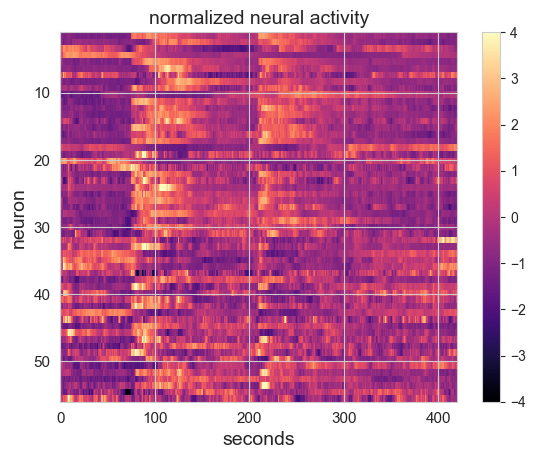

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()

im = ax.imshow(
    norm_neural.T,
    aspect='auto',
    extent=[0, t_max, n_neurons, 1],
    interpolation='none',
    vmin=-4,
    vmax=4,
    cmap='magma'
)

ax.set_xticks([0, 100, 200, 300, 400])
ax.set_xlabel('seconds', fontsize=fontsize)     # set xlabel font size
ax.set_ylabel('neuron', fontsize=fontsize)      # set ylabel font size
ax.set_title('normalized neural activity', fontsize=fontsize)  # set title font size

ax.tick_params(axis='both', which='major', labelsize=labelsize)  # set tick label size

fig.colorbar(im, ax=ax)

/Users/lucas-andreithil/.pyenv/versions/myenv/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: divide by zero encountered in matmul
  C = X.T @ X
/Users/lucas-andreithil/.pyenv/versions/myenv/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: overflow encountered in matmul
  C = X.T @ X
/Users/lucas-andreithil/.pyenv/versions/myenv/lib/python3.12/site-packages/sklearn/decomposition/_pca.py:606: RuntimeWarning: invalid value encountered in matmul
  C = X.T @ X
/Users/lucas-andreithil/.pyenv/versions/myenv/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: divide by zero encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lucas-andreithil/.pyenv/versions/myenv/lib/python3.12/site-packages/sklearn/decomposition/_base.py:148: RuntimeWarning: overflow encountered in matmul
  X_transformed = X @ self.components_.T
/Users/lucas-andreithil/.pyenv/versions/myenv/lib/python3.12/site-packag

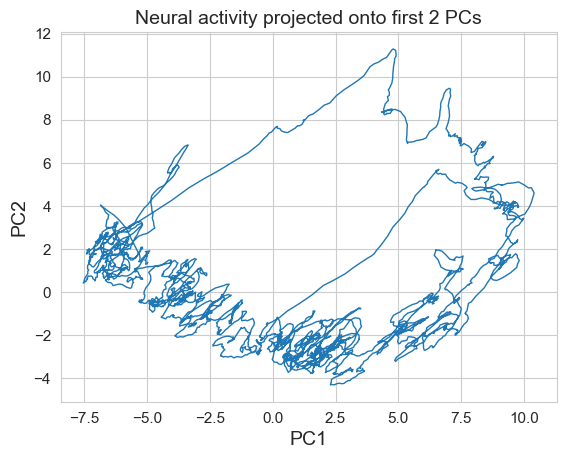

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
neural_pca = pca.fit_transform(norm_neural)

fig, ax = plt.subplots()
ax.plot(neural_pca[:, 0], neural_pca[:, 1], lw=1)

ax.set_xlabel('PC1', fontsize=fontsize)
ax.set_ylabel('PC2', fontsize=fontsize)
ax.set_title('Neural activity projected onto first 2 PCs', fontsize=fontsize)

ax.tick_params(axis='both', which='major', labelsize=labelsize)

Set up intruder timestamps

In [7]:
# Set input times
input1_times = jnp.array([74, 80]) # time interval (in seconds) of 1st intruder entrance
input2_times = jnp.array([207, 212]) # time interval (in seconds) of 2nd intruder entrance

# Convert to indices
input1_inds = (input1_times * rate).astype(int)
input2_inds = (input2_times * rate).astype(int)

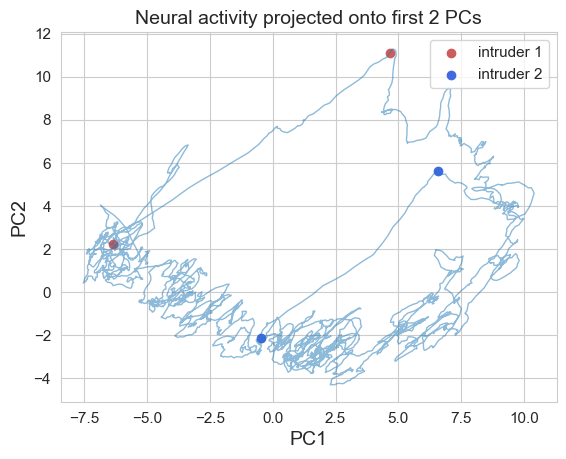

In [8]:
fig, ax = plt.subplots()

# Trajectory
ax.plot(neural_pca[:, 0], neural_pca[:, 1], lw=1, alpha=0.5)

# Intruder 1 markers
ax.scatter(neural_pca[input1_inds[0], 0], neural_pca[input1_inds[0], 1], color='indianred', label='intruder 1')
ax.scatter(neural_pca[input1_inds[1], 0], neural_pca[input1_inds[1], 1], color='indianred')

# Intruder 2 markers
ax.scatter(neural_pca[input2_inds[0], 0], neural_pca[input2_inds[0], 1], color='royalblue', label='intruder 2')
ax.scatter(neural_pca[input2_inds[1], 0], neural_pca[input2_inds[1], 1], color='royalblue')

# Labels and legend
ax.set_xlabel('PC1', fontsize=fontsize)
ax.set_ylabel('PC2', fontsize=fontsize)
ax.set_title('Neural activity projected onto first 2 PCs', fontsize=fontsize)
ax.tick_params(axis='both', which='major', labelsize=labelsize)
ax.legend(fontsize=labelsize)

Text(0.5, 0.98, 'constructed inputs')

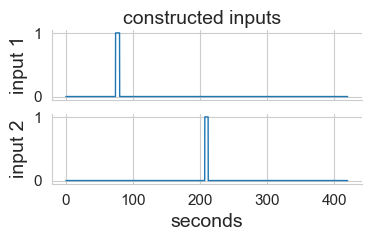

In [9]:
import numpy as np
n_inputs = 2 # one input dimension per intruder
inputs = np.zeros((n_trials, n_timesteps, n_inputs))
inputs[:,input1_inds[0]:(input1_inds[1]+1),0] = 1.
inputs[:,input2_inds[0]:(input2_inds[1]+1),1] = 1.

fig, axs = plt.subplots(n_inputs, 1, figsize=(4, 2), sharex=True)

for i, ax in enumerate(axs.ravel()):
    ax.plot(t_grid, inputs[0, :, i], lw=1)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_ylabel(f'input {i+1}', fontsize=fontsize)
    ax.tick_params(axis='both', which='major', labelsize=labelsize)

axs[1].set_xlabel('seconds', fontsize=fontsize)
fig.suptitle('constructed inputs', fontsize=fontsize)

# Prepare data for topological learning

Note:
- no bin sampling of health states is being performed.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import random
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.preprocessing import MinMaxScaler
import math
from losses.losses import combined_loss


In [11]:
def train_epoch(model, dataloader, optimizer, device, alpha=0.5, beta=0.2, margin=1.0):
    """Optimized training epoch"""
    model.train()
    total_loss = total_recon_loss = total_trip_loss = total_proto_loss = 0

    for anchor, positive, negative, anchor_rul, is_initial, is_failure, next_state in dataloader:
        anchor = anchor.float().to(device)
        positive = positive.float().to(device)
        negative = negative.float().to(device)
        next_state = next_state.float().to(device) # forecasting next window

        # With:
        if not torch.is_tensor(is_initial):
            is_initial = torch.tensor(is_initial, device=device).float()
        else:
            is_initial = is_initial.to(device).float()

        if not torch.is_tensor(is_failure):
            is_failure = torch.tensor(is_failure, device=device).float()
        else:
            is_failure = is_failure.to(device).float()

        optimizer.zero_grad()

        # Single forward pass for anchor
        recon_anchor, z_anchor = model(anchor)

        # Compute embeddings for positive and negative in single batch
        positive_negative_batch = torch.cat([positive, negative], dim=0)
        with torch.no_grad():
            _, pn_embeddings = model(positive_negative_batch)
            z_positive, z_negative = torch.chunk(pn_embeddings, 2, dim=0)

        # Compute loss
        loss, recon_loss, trip_loss, proto_loss = combined_loss(
            z_anchor, z_positive, z_negative, recon_anchor, next_state, # replaced anchor with next state for forecasting task
            z_anchor, is_initial, is_failure, model, alpha, beta, margin
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_trip_loss += trip_loss.item()
        total_proto_loss += proto_loss.item()

    n_batches = len(dataloader)
    return (total_loss / n_batches, total_recon_loss / n_batches,
            total_trip_loss / n_batches, total_proto_loss / n_batches)

# Evaluation function
@torch.no_grad()
def evaluate_model(model, dataloader, device, alpha=0.5, beta=0.2, margin=1.0):
    """Optimized evaluation"""
    model.eval()
    total_loss = total_recon_loss = total_trip_loss = total_proto_loss = 0

    for anchor, positive, negative, anchor_rul, is_initial, is_failure in dataloader:
        anchor = anchor.float().to(device)
        positive = positive.float().to(device)
        negative = negative.float().to(device)

        # With:
        if not torch.is_tensor(is_initial):
            is_initial = torch.tensor(is_initial, device=device).float()
        else:
            is_initial = is_initial.to(device).float()

        if not torch.is_tensor(is_failure):
            is_failure = torch.tensor(is_failure, device=device).float()
        else:
            is_failure = is_failure.to(device).float()

        # Forward passes
        recon_anchor, z_anchor = model(anchor)
        _, z_positive = model(positive)
        _, z_negative = model(negative)

        # Compute loss
        loss, recon_loss, trip_loss, proto_loss = combined_loss(
            z_anchor, z_positive, z_negative, recon_anchor, anchor,
            z_anchor, is_initial, is_failure, model, alpha, beta, margin
        )

        total_loss += loss.item()
        total_recon_loss += recon_loss.item()
        total_trip_loss += trip_loss.item()
        total_proto_loss += proto_loss.item()

    n_batches = len(dataloader)
    return (total_loss / n_batches, total_recon_loss / n_batches,
            total_trip_loss / n_batches, total_proto_loss / n_batches)

def create_windows(data, window_size=30, step=1, threshold=-1, dataset_test_RUL=None, forecasting=False, last_only=False):
    """Create windows with unit IDs and RUL labels, and optionally subsequent windows for forecasting

    Parameters:
    -----------
    data : dict
        Dictionary with key (unit_id), value trajectory (len * num_channels)
    window_size : int
        Size of each window
    step : int
        Step size between windows
    threshold : int or float
        Minimum RUL threshold for including windows (if negative, include all)
    dataset_test_RUL : array-like or None
        Additional RUL values to add to target RUL
    forecasting : bool
        Whether to create subsequent windows for forecasting tasks

    Returns:
    --------
    windows : np.array
        Current windows
    next_windows : np.array or None
        Subsequent windows (only if forecasting=True)
    rul_labels : np.array
        RUL labels for current windows
    unit_ids : np.array
        Unit IDs for each window
    """
    windows = []
    next_windows = [] if forecasting else None
    rul_labels = []
    unit_ids = []

    unique_units = data.keys()

    for unit_id in unique_units:
        unit_data = data[unit_id]
        n_samples = len(unit_data)

        # Adjust range based on whether we're doing forecasting
        if forecasting:
            # For forecasting, we need both current window and next window
            max_i = n_samples - window_size - 1  # -1 to ensure we have a next window
        else:
            # Original reconstruction task
            max_i = n_samples - window_size + 1

        for i in range(0, max_i, step):
            # Calculate RUL at the end of the current window
            # Since we don't have cycle numbers, RUL is remaining samples from window end
            target_rul = n_samples - (i + window_size)

            # Adjust RUL if dataset_test_RUL is provided
            if dataset_test_RUL is not None:
                # Note: unit_id might be string or integer, ensure it's properly indexed
                try:
                    # Try to use unit_id as index (assuming it's 1-based like in old function)
                    if isinstance(unit_id, str) and unit_id.isdigit():
                        target_rul += dataset_test_RUL[int(unit_id)-1]
                    else:
                        target_rul += dataset_test_RUL[unit_id-1]
                except (IndexError, KeyError, TypeError):
                    # If indexing fails, just use the original RUL
                    pass

            # Apply threshold filter (if threshold is negative, include all)
            if threshold < 0 or target_rul > threshold:
                # Current window
                window = unit_data[i:i+window_size,].flatten()
                windows.append(window)
                rul_labels.append(target_rul)
                unit_ids.append(unit_id)

                # For forecasting, add the subsequent window
                if forecasting:
                    if last_only:
                        # Takes shape [1, #features], last point only
                        next_window = unit_data[i+1+window_size,].flatten()
                    else:
                        # Takes shape [window_size, #features]
                        next_window = unit_data[i+1:i+1+window_size,].flatten()
                    next_windows.append(next_window)

    # Convert to numpy arrays
    windows_array = np.array(windows)
    rul_labels_array = np.array(rul_labels)
    unit_ids_array = np.array(unit_ids)

    if forecasting:
        next_windows_array = np.array(next_windows)
        return windows_array, next_windows_array, rul_labels_array, unit_ids_array
    else:
        return windows_array, rul_labels_array, unit_ids_array


In [13]:
# Load and prepare data
torch.manual_seed(16976296098443334824)
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu'
print(f"Using device: {device}")

# Create windows for forecasting task
window_size = 10 # 10 one window per second, other exp used size 20
R_early_train = 0
step_size = 1 # one sample every second with value of 10 (Hz)
neural_dict = {0: norm_neural} # make a dict with unit_id 0
forecasting = True # True
last_only = False # if True uses window=1, if False uses window=window_size
X_train, X_train_next, train_rul_labels, train_unit_ids = create_windows(neural_dict, window_size=window_size, step=step_size, forecasting=forecasting, last_only=last_only)
print(f'X_train: {X_train.shape}, X_train_next: {X_train_next.shape}, train_rul_labels: {train_rul_labels.shape}, train_unit_ids: {train_unit_ids.shape}')
train_rul_labels[:10]

Using device: mps
X_train: (4190, 560), X_train_next: (4190, 560), train_rul_labels: (4190,), train_unit_ids: (4190,)


array([4191, 4190, 4189, 4188, 4187, 4186, 4185, 4184, 4183, 4182])

In [14]:
from models.auto_encoders import SimpleTransformerTriplet
from vinograd.dataset import TripletWindowDataset

# Scaling
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)

# if X_train_next has a different shape than X_train, use dedicated scaler
# if X_train_next has the same shape as X_train, then use the same scaler
if last_only:
    scaler_next = MinMaxScaler()
    X_train_next_scaled = scaler_next.fit_transform(X_train_next)
else:
    scaler_next = scaler
    X_train_next_scaled = scaler_next.transform(X_train_next)

# Create datasets with prototype support
triplet_dataset = TripletWindowDataset(
    X_train_scaled, train_rul_labels, train_unit_ids, step_size=step_size,
    next_windows=X_train_next_scaled,  # Add next windows for forecasting
    #margin=20, health_margin=40, n_initial_prototypes=50, n_failure_prototypes=50
    margin=10, health_margin=30, n_initial_prototypes=5, n_failure_prototypes=5
)

# normal with step=1 used margin=200, health_margin=400, step=10 used margin=20, health_margin=40

# Create dataloaders with multiple workers
batch_size = 256  # Increased batch size
num_workers = 64 if device == 'cuda' else 0

triplet_loader = DataLoader(
    triplet_dataset, batch_size=batch_size, shuffle=True,
    num_workers=num_workers, pin_memory=True
)
# Initialize model
input_dim = X_train_scaled.shape[1]
output_dim = X_train_next.shape[1]
latent_dim = 4
model = SimpleTransformerTriplet(input_dim, output_dim=output_dim, latent_dim=latent_dim, d_model=32, nhead=8, num_layers=4, dropout=0.1).to(device)

# Use more efficient optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0005, weight_decay=0.01, betas=(0.9, 0.98))
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=500)

# Training configuration
num_epochs = 80
alpha = 1.0 # 0.7  # Triplet loss weight
beta = 1.0 # 0.3   # Prototype loss weight
margin = 10.0

In [15]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params}")
print(f"Trainable parameters: {trainable_params}")

Total parameters: 294196
Trainable parameters: 294196


In [16]:
# Track losses
train_losses, train_recon_losses, train_trip_losses, train_proto_losses = [], [], [], []
test_losses, test_recon_losses, test_trip_losses, test_proto_losses = [], [], [], []

best_test_loss = float('inf')
best_model_wts = None

In [17]:
print("Starting training...")
for epoch in range(num_epochs):

    current_beta = max(0.3 * (0.95 ** epoch), 0.05)

    # Training
    train_metrics = train_epoch(model, triplet_loader, optimizer, device, alpha, current_beta, margin)
    avg_train_loss, avg_train_recon, avg_train_trip, avg_train_proto = train_metrics

    # Store metrics
    train_losses.append(avg_train_loss)
    train_recon_losses.append(avg_train_recon)
    train_trip_losses.append(avg_train_trip)
    train_proto_losses.append(avg_train_proto)

    scheduler.step()

    # Save best model
    if avg_train_loss < best_test_loss:
        best_test_loss = avg_train_loss
        best_model_wts = model.state_dict().copy()
        print(f'>>> Best model at epoch {epoch+1} (Test Loss: {best_test_loss:.4f})')

    # Print progress
    if (epoch + 1) % 20 == 0 or True:
        print(f'Epoch {epoch+1}/{num_epochs}: '
              f'Train Loss: {avg_train_loss:.4f} | '
              f'Recon: {avg_train_recon:.4f} | '
              f'Trip: {avg_train_trip:.4f} | '
              f'Proto: {avg_train_proto:.4f}')

# Restore best model
# model.load_state_dict(best_model_wts)
print(f'\nTraining complete. Best Test Loss: {best_test_loss:.4f}')

Starting training...


/Users/lucas-andreithil/.pyenv/versions/myenv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:683: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


>>> Best model at epoch 1 (Test Loss: 9.5585)
Epoch 1/80: Train Loss: 9.5585 | Recon: 0.1649 | Trip: 9.3618 | Proto: 0.1061
>>> Best model at epoch 2 (Test Loss: 9.1817)
Epoch 2/80: Train Loss: 9.1817 | Recon: 0.0944 | Trip: 9.0626 | Proto: 0.0869
>>> Best model at epoch 3 (Test Loss: 9.0650)
Epoch 3/80: Train Loss: 9.0650 | Recon: 0.0448 | Trip: 9.0020 | Proto: 0.0672
Epoch 4/80: Train Loss: 9.0917 | Recon: 0.0342 | Trip: 9.0418 | Proto: 0.0613
>>> Best model at epoch 5 (Test Loss: 9.0628)
Epoch 5/80: Train Loss: 9.0628 | Recon: 0.0291 | Trip: 9.0199 | Proto: 0.0566
>>> Best model at epoch 6 (Test Loss: 9.0508)
Epoch 6/80: Train Loss: 9.0508 | Recon: 0.0259 | Trip: 9.0065 | Proto: 0.0791
>>> Best model at epoch 7 (Test Loss: 9.0206)
Epoch 7/80: Train Loss: 9.0206 | Recon: 0.0252 | Trip: 8.9833 | Proto: 0.0549
Epoch 8/80: Train Loss: 9.0623 | Recon: 0.0248 | Trip: 9.0257 | Proto: 0.0559
Epoch 9/80: Train Loss: 9.0454 | Recon: 0.0246 | Trip: 9.0075 | Proto: 0.0669
Epoch 10/80: Train Los

In [19]:
#torch.save(model.state_dict(), f=f"vinograd_forecasting_w{window_size}_s{step_size}_cleaned_recon_ONLY.pth")
model.eval()
window_size, step_size

(10, 1)

In [18]:
import torch

import torch

# 1. Recreate your model architecture #_w{window_size}
#state_dict = torch.load(f'vinograd_forecasting_w{window_size}_s{step_size}_best.pth', map_location=torch.device('cpu'), weights_only=True)
print(window_size, step_size)
# 1. Recreate your model architecture #_w{window_size}
# state_dict = torch.load(f'vinograd_forecasting_w{window_size}_s{step_size}_cleaned_recon.pth', map_location=torch.device('cpu'), weights_only=True)
# model.load_state_dict(state_dict)
model = model.to(device)
model.eval()


10 1


SimpleTransformerTriplet(
  (input_projection): Linear(in_features=560, out_features=32, bias=True)
  (pos_encoding): SimplePositionalEncoding(
    (dropout): Dropout(p=0.1, inplace=False)
  )
  (transformer): TransformerEncoder(
    (layers): ModuleList(
      (0-3): 4 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=32, out_features=32, bias=True)
        )
        (linear1): Linear(in_features=32, out_features=64, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=64, out_features=32, bias=True)
        (norm1): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (pool): AdaptiveAvgPool1d(output_size=1)
  (latent_projection): Sequential(
    (0): Linear(in_features=

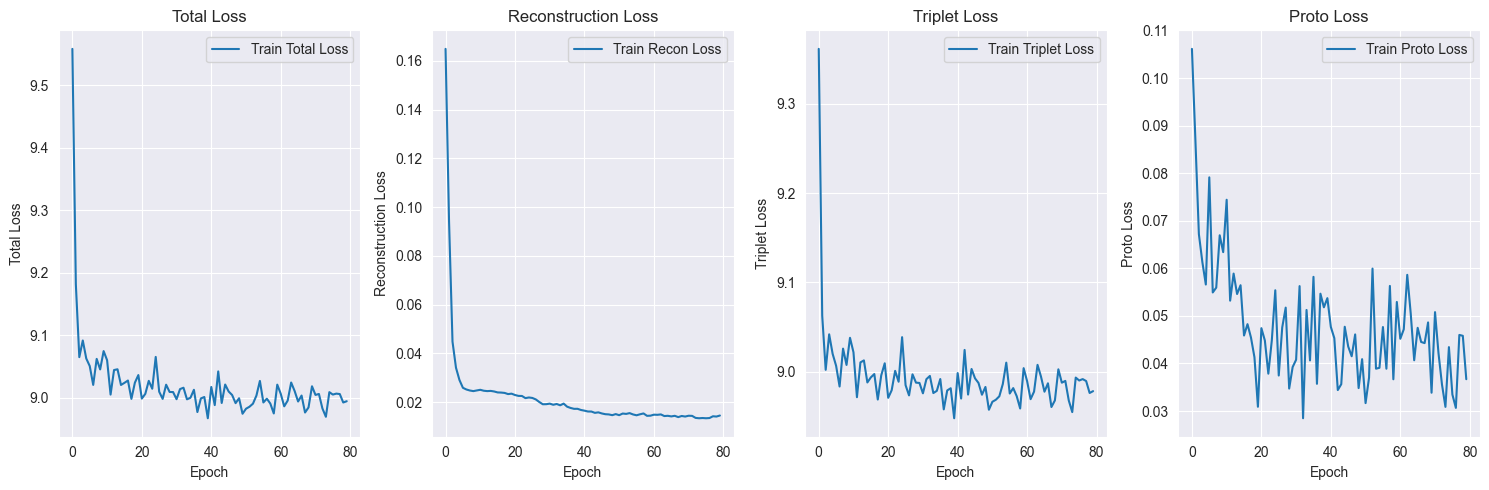

In [19]:
import matplotlib.pyplot as plt

# Plotting the losses
plt.figure(figsize=(15, 5))

# Total Loss
plt.subplot(1, 4, 1)
plt.plot(train_losses, label='Train Total Loss')
plt.xlabel('Epoch')
plt.ylabel('Total Loss')
plt.title('Total Loss')
plt.legend()
plt.grid(True)

# Reconstruction Loss
plt.subplot(1, 4, 2)
plt.plot(train_recon_losses, label='Train Recon Loss')
plt.xlabel('Epoch')
plt.ylabel('Reconstruction Loss')
plt.title('Reconstruction Loss')
plt.legend()
plt.grid(True)

# Triplet Loss
plt.subplot(1, 4, 3)
plt.plot(train_trip_losses, label='Train Triplet Loss')  # Remove .cpu()
plt.xlabel('Epoch')
plt.ylabel('Triplet Loss')
plt.title('Triplet Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 4, 4)
plt.plot(train_proto_losses, label='Train Proto Loss')  # Remove .cpu()
plt.xlabel('Epoch')
plt.ylabel('Proto Loss')
plt.title('Proto Loss')
plt.legend()
plt.grid(True)


plt.tight_layout()
plt.show()

In [20]:
# MAYBE DELETE
# Reload dataset and do processing to have the right windows

# If we have last only, reload here to match the dim and compute the next_state latents.
if last_only:
    _, X_train_next_2, _, _ = create_windows(neural_dict, window_size=window_size, step=step_size, forecasting=forecasting, last_only=False)
    print(f'X_train_next: {X_train_next_2.shape}')

    # Scaling
    # then use the same scaler as the input data
    X_train_next_scaled_2 = scaler.transform(X_train_next_2)
else:
    X_train_next_scaled_2 = X_train_next_scaled

In [21]:
from latent_his.extract_latent import extract_latent_representations
from sklearn.preprocessing import StandardScaler, Normalizer


model.to(device)

# Usage with your transformer model:
model.eval()
with torch.no_grad():
    # Get latent vectors for training data
    z_train = extract_latent_representations(model, X_train_scaled, device)
    # z_train_next = extract_latent_representations(model, X_train_next, device)
    z_train_next = extract_latent_representations(model, X_train_next_scaled_2, device)


# Scale latent vectors (optional - depends on your use case)
scaler_z = StandardScaler()
#scaler_z = Normalizer() # if want to test with a Normalizer scaler
z_train_scaled = scaler_z.fit_transform(z_train)
z_train_next_scaled = scaler_z.transform(z_train_next)

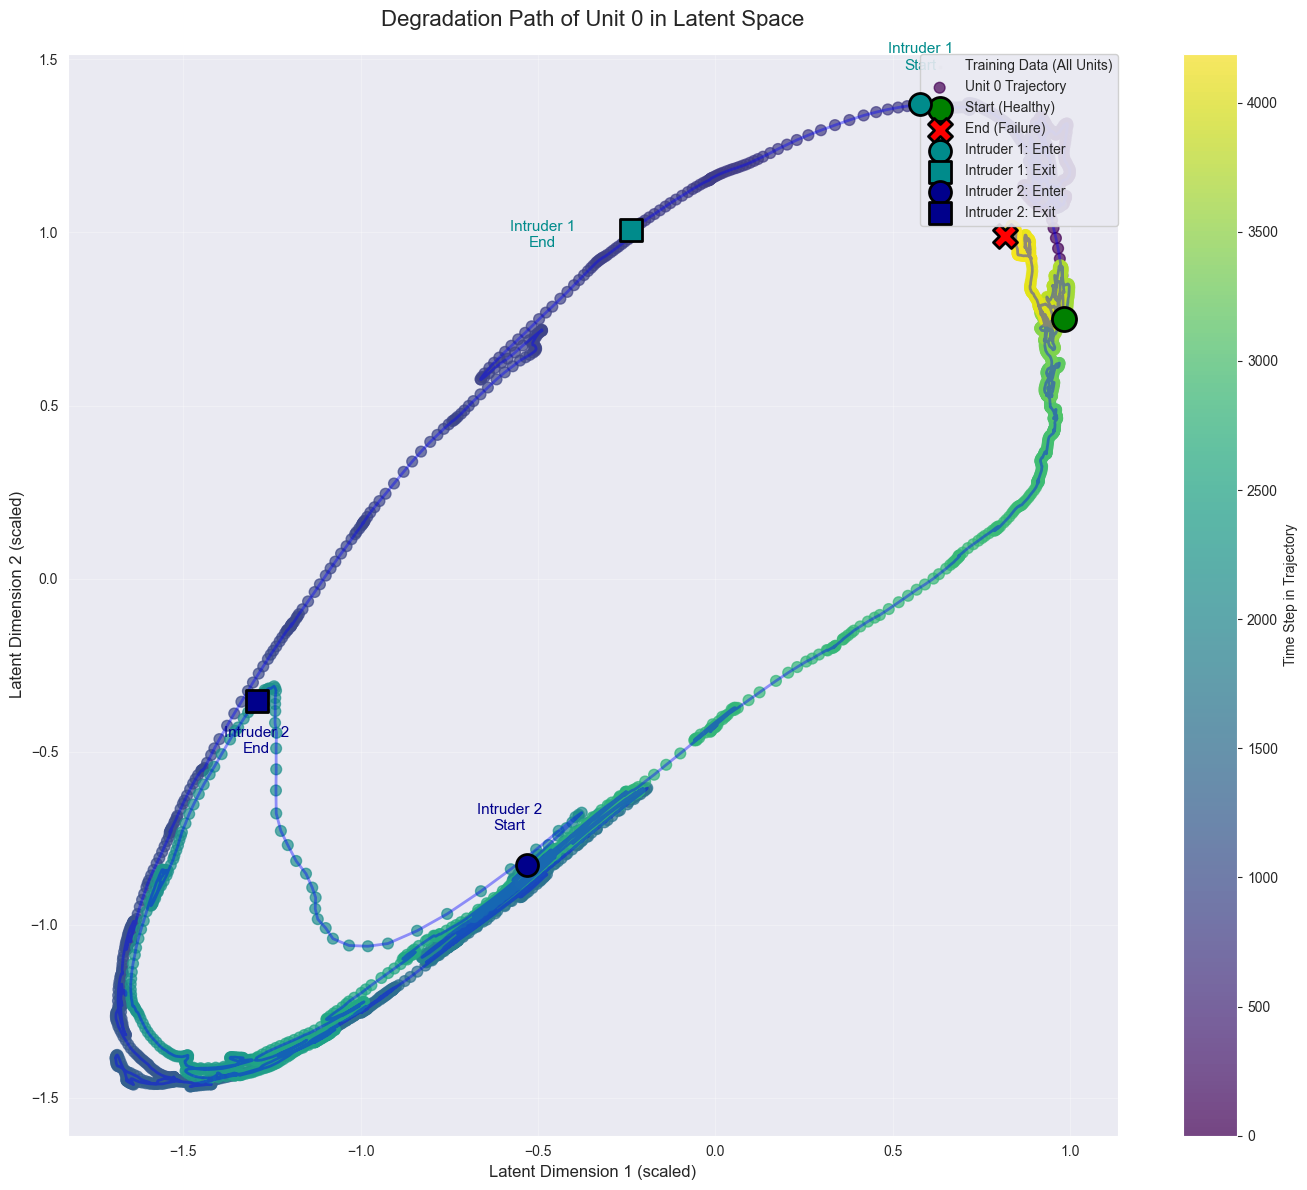


SCALING VERIFICATION:
Train latent range: (-1.69, 2.34)
Traj latent range: (-1.69, 2.34)
Trajectory length: 4190 points

Intruder 1: Enters at step 740.0, Leaves at step 800.0 (duration: 60.0)
Intruder 2: Enters at step 2070.0, Leaves at step 2120.0 (duration: 50.0)
X_train_next_scaled: (4190, 560), recon: (4190, 560)


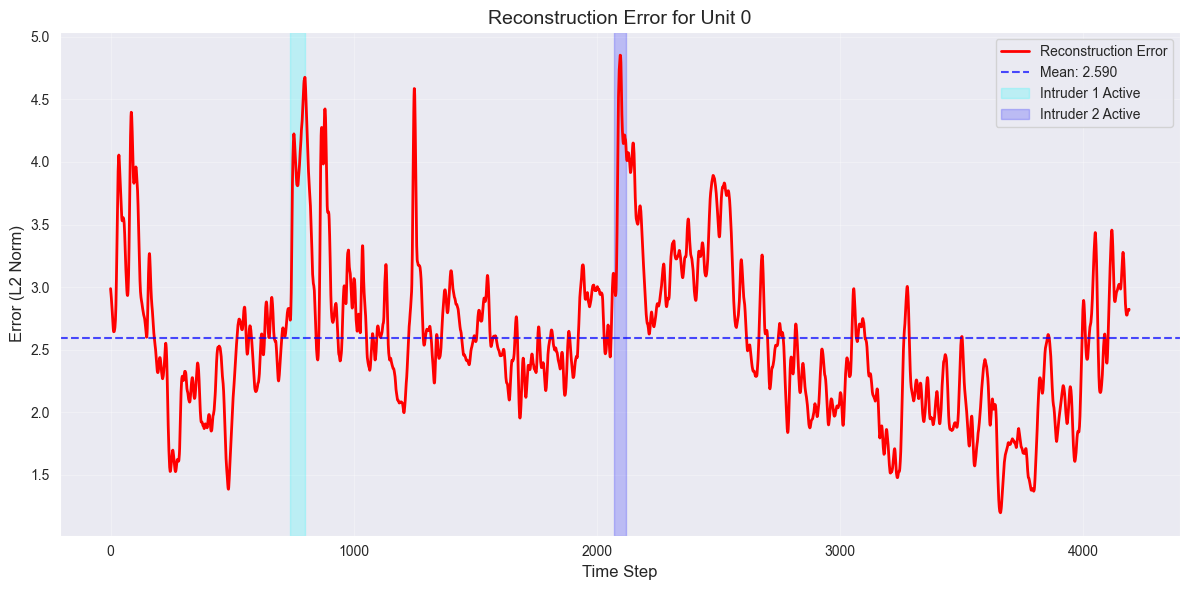

In [22]:
unit_id = 0

# Create windows for trajectory (same as training)
traj_windows = X_train

# Scale using SAME scaler
traj_windows_scaled = scaler.transform(traj_windows)

# Extract latent representations
with torch.no_grad():
    z_traj = extract_latent_representations(model, traj_windows_scaled, device)
z_traj_scaled = scaler_z.transform(z_traj)

# 6. VISUALIZE WITH WATERFALL PLOT
plt.figure(figsize=(14, 12))

# Plot training data as background (with more transparency for better visibility)
plt.scatter(z_train_scaled[:, 0], z_train_scaled[:, 1],
            c='lightgray', alpha=0.05, s=3, label='Training Data (All Units)')

# Plot trajectory with color gradient
scatter = plt.scatter(z_traj_scaled[:, 0], z_traj_scaled[:, 1],
            c=np.arange(len(z_traj_scaled)),
            cmap='viridis', s=60, alpha=0.7,
            label=f'Unit {unit_id} Trajectory')

# Connect points with lines (thicker and more visible)
plt.plot(z_traj_scaled[:, 0], z_traj_scaled[:, 1],
         'b-', alpha=0.4, linewidth=2, zorder=1)

# Add markers with larger sizes and borders
plt.scatter(z_traj_scaled[0, 0], z_traj_scaled[0, 1],
            c='green', s=300, marker='o', edgecolor='k', linewidth=2,
            label='Start (Healthy)', zorder=5)
plt.scatter(z_traj_scaled[-1, 0], z_traj_scaled[-1, 1],
            c='red', s=300, marker='X', edgecolor='k', linewidth=2,
            label='End (Failure)', zorder=5)

enters1 = int(input1_inds[0]/step_size)
leaves1 = int(input1_inds[1]/step_size)
enters2 = int(input2_inds[0]/step_size)
leaves2 = int(input2_inds[1]/step_size)


# Intruder events with larger, more distinct markers
# Using different shapes and colors for clarity
plt.scatter(z_traj_scaled[enters1, 0], z_traj_scaled[enters1, 1],
            color='darkcyan', s=250, marker='o', edgecolor='k', linewidth=2,
            label='Intruder 1: Enter', zorder=6)
plt.scatter(z_traj_scaled[leaves1, 0], z_traj_scaled[leaves1, 1],
            color='darkcyan', s=250, marker='s', edgecolor='k', linewidth=2,
            label='Intruder 1: Exit', zorder=6)
plt.scatter(z_traj_scaled[enters2, 0], z_traj_scaled[enters2, 1],
            color='darkblue', s=250, marker='o', edgecolor='k', linewidth=2,
            label='Intruder 2: Enter', zorder=6)
plt.scatter(z_traj_scaled[leaves2, 0], z_traj_scaled[leaves2, 1],
            color='darkblue', s=250, marker='s', edgecolor='k', linewidth=2,
            label='Intruder 2: Exit', zorder=6)

# Add text labels near intruder events for clarity
plt.text(z_traj_scaled[enters1, 0], z_traj_scaled[enters1, 1]+0.10,
         'Intruder 1\nStart', fontsize=11, ha='center', color='darkcyan')
plt.text(z_traj_scaled[leaves1, 0]-0.25, z_traj_scaled[leaves1, 1]-0.05,
         'Intruder 1\nEnd', fontsize=11, ha='center', color='darkcyan')
plt.text(z_traj_scaled[enters2, 0]-0.05, z_traj_scaled[enters2, 1]+0.10,
         'Intruder 2\nStart', fontsize=11, ha='center', color='darkblue')
plt.text(z_traj_scaled[leaves2, 0], z_traj_scaled[leaves2, 1]-0.15,
         'Intruder 2\nEnd', fontsize=11, ha='center', color='darkblue')

# Add direction arrow (larger and more prominent)
if len(z_traj_scaled) > 1 and False:
    mid_point = len(z_traj_scaled) // 2
    plt.annotate('Time →',
                xytext=(z_traj_scaled[mid_point-1, 0], z_traj_scaled[mid_point-1, 1]),
                xy=(z_traj_scaled[mid_point, 0], z_traj_scaled[mid_point, 1]),
                arrowprops=dict(arrowstyle='fancy', color='black', lw=2, alpha=0.9),
                fontsize=10, color='black', ha='center', va='center')

plt.colorbar(scatter, label='Time Step in Trajectory')
plt.title(f'Degradation Path of Unit {unit_id} in Latent Space', fontsize=16, pad=20)
plt.xlabel('Latent Dimension 1 (scaled)', fontsize=12)
plt.ylabel('Latent Dimension 2 (scaled)', fontsize=12)

# Improve legend: group similar items and place outside
handles, labels = plt.gca().get_legend_handles_labels()
# Reorder if needed: trajectory events first, then intruders
plt.legend(handles, labels, loc='upper right', #bbox_to_anchor=(1.02, 1),
           borderaxespad=0, framealpha=0.9)

plt.grid(True, alpha=0.3)
plt.tight_layout()  # Make room for legend rect=[0, 0, 0.85, 1]
plt.show()

# 7. DIAGNOSTICS
print("\n" + "="*60)
print("SCALING VERIFICATION:")
print("="*60)
print(f"Train latent range: ({z_train_scaled.min():.2f}, {z_train_scaled.max():.2f})")
print(f"Traj latent range: ({z_traj_scaled.min():.2f}, {z_traj_scaled.max():.2f})")
print(f"Trajectory length: {len(z_traj_scaled)} points")

# Calculate and print intruder timing statistics
if 'input1_inds' in locals() and 'input2_inds' in locals():
    print(f"\nIntruder 1: Enters at step {input1_inds[0]/step_size}, Leaves at step {input1_inds[1]/step_size} (duration: {input1_inds[1]/step_size-input1_inds[0]/step_size})")
    print(f"Intruder 2: Enters at step {input2_inds[0]/step_size}, Leaves at step {input2_inds[1]/step_size} (duration: {input2_inds[1]/step_size-input2_inds[0]/step_size})")

# Reconstruction error
model.eval()
with torch.no_grad():
    recon = model(torch.FloatTensor(traj_windows_scaled).to(device))[0].cpu().numpy()
#errors = np.linalg.norm(abs(traj_windows_scaled - recon), axis=1)
print(f'X_train_next_scaled: {X_train_next_scaled.shape}, recon: {recon.shape}')
errors = np.linalg.norm(abs(X_train_next_scaled - recon), axis=1)


plt.figure(figsize=(12, 6))
plt.plot(errors, 'r-', linewidth=2, label='Reconstruction Error')
plt.axhline(y=np.mean(errors), color='b', linestyle='--', alpha=0.7, label=f'Mean: {np.mean(errors):.3f}')

# Mark intruder periods on error plot
if 'input1_inds' in locals():
    plt.axvspan(enters1, leaves1, alpha=0.2, color='cyan', label='Intruder 1 Active')
if 'input2_inds' in locals():
    plt.axvspan(enters2, leaves2, alpha=0.2, color='blue', label='Intruder 2 Active')

plt.title(f'Reconstruction Error for Unit {unit_id}', fontsize=14)
plt.xlabel('Time Step', fontsize=12)
plt.ylabel('Error (L2 Norm)', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [26]:
input1_inds, input2_inds

(Array([740, 800], dtype=int32), Array([2070, 2120], dtype=int32))

## Get angles

In [42]:


from latent_his.angle_his import get_angles_from_trajectory

unit_id = 50
angles = get_angles_from_trajectory(model, traj_windows, scaler=scaler, latent_scale=False)
angles # shape (len,)

traj_windows_scaled: (4190, 560)


array([0.63752553, 0.6381837 , 0.64155685, ..., 0.95624063, 0.95684312,
       0.95884314], shape=(4190,))

In [43]:
from latent_his.angle_his import compute_global_alignment_offset

# Usage examples:

# 1. First, compute global offset with reference trajectories
print("=== COMPUTING GLOBAL OFFSET ===")
traj_windows_scaled = scaler.transform(traj_windows)
reference_trajectories = [traj_windows_scaled]  # Your healthy/normal trajectories
global_offset = compute_global_alignment_offset(reference_trajectories, model, k=8) + 0.05 # 0.1 is a safety margin for angle wrapping



=== COMPUTING GLOBAL OFFSET ===
Computed global alignment offset: -0.652273 rad



=== FULL TRAJECTORY EXAMPLE ===


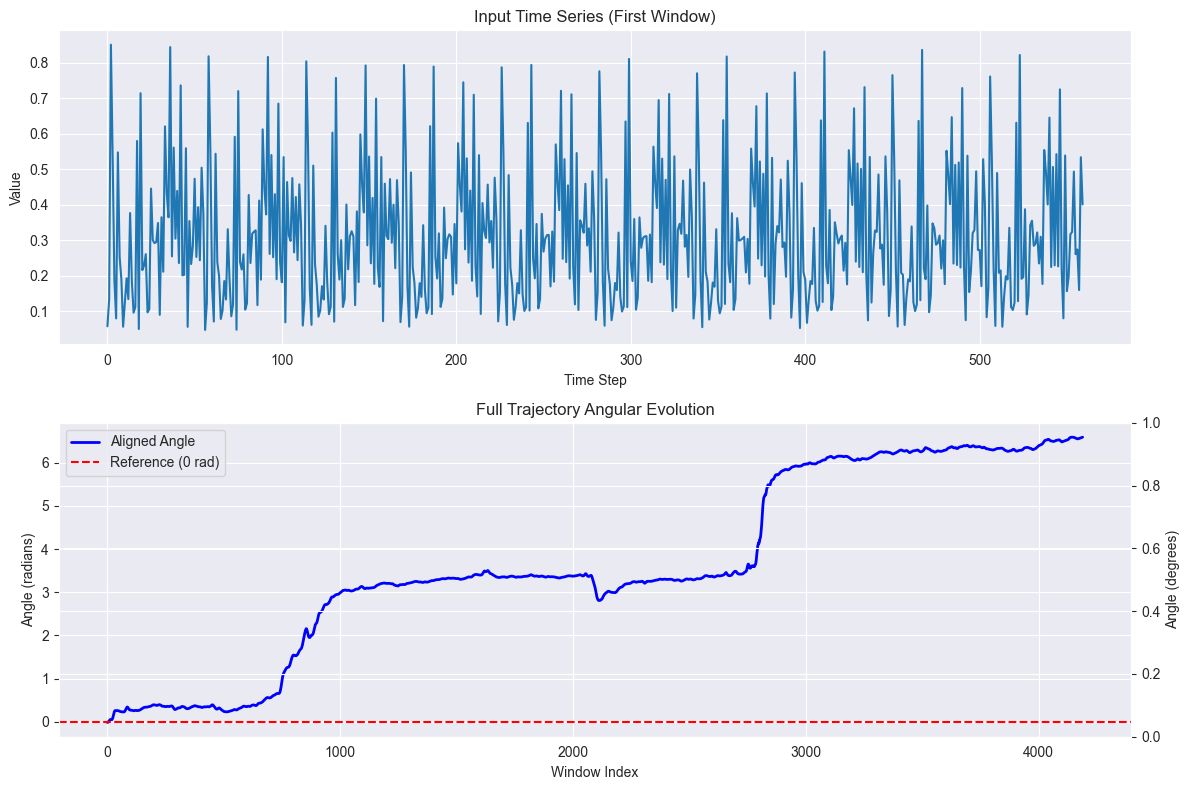

In [44]:
from latent_his.angle_his import get_aligned_angles_for_data, plot_angular_evolution

# 3. Use with full trajectories
print("\n=== FULL TRAJECTORY EXAMPLE ===")
full_trajectory_angles = get_aligned_angles_for_data(traj_windows_scaled, model, mode='trajectory')
plot_angular_evolution(traj_windows_scaled, full_trajectory_angles, "Full Trajectory Angular Evolution");


In [45]:
input1_inds, input2_inds

(Array([740, 800], dtype=int32), Array([2070, 2120], dtype=int32))

# TODO: remove bins in sampling, and instead just randomly sample from dataset with a margin between similar and dissimilar states.

because above we just have the margins being displayed.

## Latent forecasting

In [46]:

# DELETE THIS CELL

def compute_predictive_r2(model, trajectory_windows, trajectory_next_windows, num_initial_points=20, max_forecast_steps=15, scaler=None, device='cuda'):
    """
    Compute R^2 predictive metric as described in the paper.

    Args:
        model: The trained model
        trajectory_windows: All trajectory windows (n_windows, window_size, n_features)
        trajectory_next_windows: Corresponding next windows for each trajectory window
        num_initial_points: Number of uniformly spaced starting points (t0)
        max_forecast_steps: Maximum number of steps to forecast forward
        scaler: Optional scaler for preprocessing inputs
        device: Device to run computations on

    Returns:
        r2_scores: Array of R^2 scores for each forecast step (1 to max_forecast_steps)
        predictions_dict: Dictionary containing predictions for analysis
    """
    model.eval()

    # Select uniformly spaced initial time points
    n_windows = len(trajectory_windows)
    indices = np.linspace(0, n_windows - max_forecast_steps - 1, num_initial_points, dtype=int)

    # Pre-compute all observations (y) and their global mean
    # In our case, y(t) is the next window at time t
    all_observations = trajectory_next_windows  # Shape: (n_windows, window_size, n_features)
    y_bar = np.mean(all_observations, axis=0)  # Mean observation across all windows

    # Dictionary to store predictions
    predictions_dict = {}

    with torch.no_grad():
        for s in range(1, max_forecast_steps + 1):
            total_squared_error = 0
            total_variance = 0

            for t0_idx in indices:
                # Get initial window at t0
                window_t0 = trajectory_windows[t0_idx]

                # Convert to tensor and add batch dimension
                x_t0 = torch.tensor(window_t0, dtype=torch.float32).to(device).unsqueeze(0)

                # Forecast s steps ahead
                x_batch = x_t0
                for _ in range(s):
                    x_t1, _ = model(x_batch)  # We get both reconstruction and latent
                    x_batch = x_t1  # Autoregressive feeding

                # Get predicted observation: y_hat(t0 + s)
                y_hat = x_t1.detach().cpu().numpy().squeeze(0)

                # Get actual observation: y(t0 + s)
                y_actual = trajectory_next_windows[t0_idx + s - 1]  # Note: -1 because next_windows[t0] is at t0+1

                # Scale back if scaler was used (assuming scaler was fitted on windows)
                if scaler is not None:
                    y_hat = scaler.inverse_transform(y_hat.reshape(1, -1)).reshape(y_hat.shape)
                    y_actual = scaler.inverse_transform(y_actual.reshape(1, -1)).reshape(y_actual.shape)

                # Store predictions for analysis
                if s not in predictions_dict:
                    predictions_dict[s] = {'predicted': [], 'actual': [], 't0_indices': []}
                predictions_dict[s]['predicted'].append(y_hat)
                predictions_dict[s]['actual'].append(y_actual)
                predictions_dict[s]['t0_indices'].append(t0_idx)

                # Compute squared error for this t0 and s
                squared_error = np.sum((y_hat - y_actual) ** 2)
                total_squared_error += squared_error

                # Compute variance term for this t0 and s
                variance_term = np.sum((y_actual - y_bar) ** 2)
                total_variance += variance_term

            # Convert lists to arrays
            predictions_dict[s]['predicted'] = np.array(predictions_dict[s]['predicted'])
            predictions_dict[s]['actual'] = np.array(predictions_dict[s]['actual'])

    # Compute R^2 for each forecast step
    r2_scores = []
    for s in range(1, max_forecast_steps + 1):
        # Get aggregated errors for this s
        preds = predictions_dict[s]['predicted']
        actuals = predictions_dict[s]['actual']

        total_squared_error = np.sum((preds - actuals) ** 2)
        total_variance = np.sum((actuals - y_bar) ** 2)

        if total_variance == 0:
            r2 = 0
        else:
            r2 = 1 - (total_squared_error / total_variance)

        r2_scores.append(r2)

    return np.array(r2_scores), predictions_dict

def vanilla_forecast(window, model, forecasting_steps, traj_next_windows=None,
                     latent_scale=False, compute_r2=False, global_offset=None,
                     scaler=None):
    '''
    Feeds output back to the input to try to do forecasting over n forecasting_steps

    Args:
        window: window at t=0 to start the forecast
        model: backbone model
        forecasting_steps: number of steps to forecast
        traj_next_windows: actual next windows for error computation (optional)
        latent_scale: whether to scale the latent space
        compute_r2: whether to compute R^2 metric
        global_offset: for angle computation
        scaler: scaler for inverse transformation (if compute_r2=True)

    Returns:
        Dictionary containing forecasts and metrics
    '''
    model.eval()
    x_batch = torch.tensor(window, dtype=torch.float32).to(device).unsqueeze(0)

    x_ts = []
    z_ts = []

    with torch.no_grad():
        for n in range(forecasting_steps):
            x_t1, z_t = model(x_batch)
            x_ts.append(x_t1.detach().cpu().numpy())
            z_t = z_t.detach().cpu().numpy()

            # scale the latent if we want to, or keep it vanilla
            if latent_scale:
                z_t = scaler_z.transform(z_t)

            z_ts.append(z_t.squeeze(0))
            x_batch = x_t1

    x_ts = np.array(x_ts).squeeze(1)
    z_ts = np.array(z_ts)

    # Compute angles if global_offset is provided
    angles_2d = None
    if global_offset is not None:
        angles_2d = compute_aligned_angles(z_ts, global_offset, mode='single')

    # Initialize results dictionary
    results = {
        'x_ts': x_ts,
        'z_ts': z_ts,
        'angles_2d': angles_2d,
    }

    # Compute forecast errors if actual next windows are provided
    if traj_next_windows is not None:
        forecast_step_errors = np.linalg.norm(abs(x_ts - traj_next_windows), axis=1)
        results['forecast_step_errors'] = forecast_step_errors

        # Compute R^2 if requested
        if compute_r2 and scaler is not None:
            # Inverse transform for proper comparison
            x_ts_inv = scaler.inverse_transform(x_ts.reshape(-1, x_ts.shape[-1])).reshape(x_ts.shape)
            traj_next_inv = scaler.inverse_transform(traj_next_windows.reshape(-1, traj_next_windows.shape[-1])).reshape(traj_next_windows.shape)

            # Compute mean observation
            y_bar = np.mean(traj_next_inv, axis=0)

            # Compute R^2 for each step
            r2_scores = []
            for i in range(forecasting_steps):
                total_squared_error = np.sum((x_ts_inv[i] - traj_next_inv[i]) ** 2)
                total_variance = np.sum((traj_next_inv[i] - y_bar) ** 2)

                if total_variance == 0:
                    r2 = 0
                else:
                    r2 = 1 - (total_squared_error / total_variance)
                r2_scores.append(r2)

            results['r2_scores'] = np.array(r2_scores)

    return results

unit_id = 1
#sample = process_dataset(dataset_train, unit_id=unit_id) # get unit_id trajectory
#traj_windows, traj_next_windows, traj_rul, _ = create_windows(sample, window_size=window_size, threshold=-1)
#traj_windows = scaler.transform(traj_windows)
#traj_next_windows = scaler.transform(traj_next_windows)

traj_windows_scaled = scaler.transform(traj_windows)
traj_next_windows = X_train_next
traj_next_windows = scaler.transform(traj_next_windows)


start_index = 200
forecasting_steps = 15
results = vanilla_forecast(traj_windows[start_index], model, forecasting_steps=forecasting_steps, traj_next_windows=traj_next_windows[start_index:start_index+forecasting_steps])

# Compute traditional iterative reconstruction error
x_ts = results['x_ts']
iterative_recon_error = np.sqrt(np.mean(np.square(x_ts[-1] - traj_next_windows[start_index+forecasting_steps-1])))
print(f'Iterative reconstruction error: {iterative_recon_error}')

if 'forecast_step_errors' in results:
    print(f'Forecast step errors: {results["forecast_step_errors"]}')
if 'r2_scores' in results:
    print(f'R^2 scores: {results["r2_scores"]}')

Iterative reconstruction error: 0.12078728815625239
Forecast step errors: [2.48197695 2.57153687 2.66851959 2.75153522 2.81724394 2.86070424
 2.88775752 2.90231489 2.90187538 2.89678123 2.89470275 2.89174947
 2.88253303 2.87051609 2.85834893]



Computing full predictive R^2 metric...


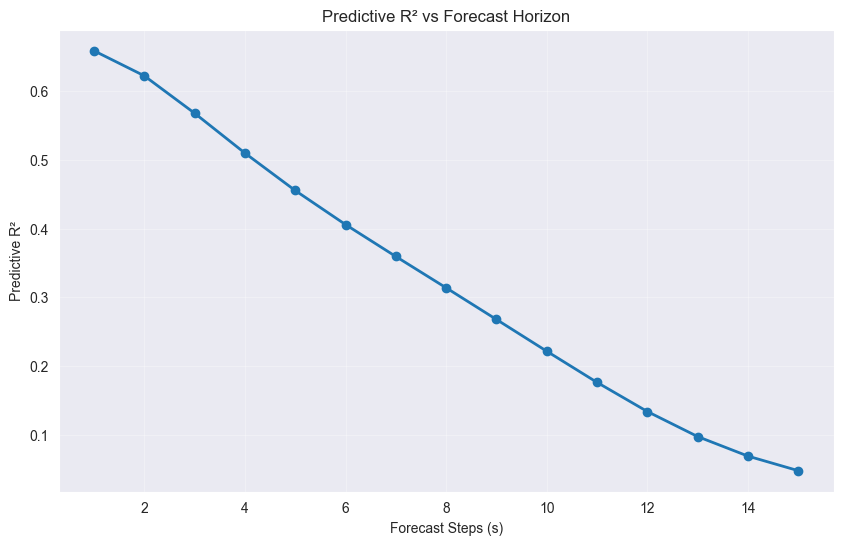

R² scores by forecast step: {1: np.float64(0.6591752714740082), 2: np.float64(0.6226975565116369), 3: np.float64(0.5682045575171908), 4: np.float64(0.5101075516188622), 5: np.float64(0.45552646383500217), 6: np.float64(0.4059157845634517), 7: np.float64(0.35938746412308364), 8: np.float64(0.3137203074869678), 9: np.float64(0.26759811981253223), 10: np.float64(0.2213104166061891), 11: np.float64(0.1758690888105121), 12: np.float64(0.13340733005591576), 13: np.float64(0.09693747870442737), 14: np.float64(0.06846601104141625), 15: np.float64(0.04724838681492116)}


array([0.63752553, 0.6381837 , 0.64155685, ..., 0.95624063, 0.95684312,
       0.95884314], shape=(4190,))

In [47]:
# DELETE THIS CELL

# problem: for iterative forecasting it is ok to predict, but if we use the raw latents to train a model, might be trickier because we have no train/test separation. Maybe use angular progression or something

# Compute full R^2 metric using the dedicated function
print("\nComputing full predictive R^2 metric...")
r2_scores, predictions_dict = compute_predictive_r2(
    model=model,
    trajectory_windows=traj_windows,
    trajectory_next_windows=traj_next_windows,
    num_initial_points=20,
    max_forecast_steps=15, # 15s but check discretization hyperparams
    scaler=scaler,
    device=device
)

# Compute p(\hat{x_t}|x_t-1,...x_0) recon error (traditional method)
iterative_recong_error = np.sqrt(np.mean(np.square(x_ts[-1] - traj_next_windows[start_index+forecasting_steps])))
#print(f'iterative_recong_error: {iterative_recong_error}, forecast_step_errors: {forecast_step_errors}')

# Plot R^2 scores
plt.figure(figsize=(10, 6))
plt.plot(range(1, 16), r2_scores, marker='o', linewidth=2)
plt.xlabel('Forecast Steps (s)')
plt.ylabel('Predictive R²')
plt.title('Predictive R² vs Forecast Horizon')
plt.grid(True, alpha=0.3)
plt.show()
print(f"R² scores by forecast step: {dict(zip(range(1, 16), r2_scores))}")

angles

## Latent Forecaster with Discretization

For latent forecasting, train transformer to predict $z_{t+1}$ from $z_t$, and check forecasting horizon.


IMPORTANT: it seems that we measured the score on the reconstruction, and not on the direct latent!

## Reprepare data and discretization

In [48]:
forecast_stepsize = 10
# Create windows for forecasting task
# lucas update: either w=1 & s=10, or w=10 & s=10 but dependent on backbone wç
#window_size = 10 # 10 Hz ie. one window per second, other exp used size 20
forecasting = True
X_train_forecast, X_train_next_forecast, train_rul_labels_forecast, train_unit_ids_forecast = create_windows(neural_dict, window_size=window_size, step=forecast_stepsize, forecasting=forecasting, last_only=last_only)
print(f'X_train: {X_train_forecast.shape}, X_train_next: {X_train_next_forecast.shape}, train_rul_labels: {train_rul_labels_forecast.shape}, train_unit_ids: {train_unit_ids_forecast.shape}')


# Scaling
#scaler_forecast = MinMaxScaler()
#X_train_scaled_forecast = scaler_forecast.fit_transform(X_train_forecast)
#X_train_next_forecast_scaled = scaler_forecast.transform(X_train_next_forecast)
X_train_scaled_forecast = scaler.transform(X_train_forecast) # must reuse same scaler for model
X_train_next_forecast_scaled = scaler.transform(X_train_next_forecast)

# Usage with your transformer model:
model.eval()
with torch.no_grad():
    # Get latent vectors for training data
    z_train = extract_latent_representations(model, X_train_scaled_forecast, device)
    # z_train_next = extract_latent_representations(model, X_train_next, device)
    z_train_next = extract_latent_representations(model, X_train_next_forecast_scaled, device)


# Scale latent vectors (optional - depends on your use case)
scaler_z = StandardScaler() # reuse previous scaler, OR MAYBE DEFINE A DEDICATED SCALER
#scaler_z = Normalizer() # if want to test with a Normalizer scaler
z_train_scaled = scaler_z.fit_transform(z_train)
z_train_next_scaled = scaler_z.transform(z_train_next)

print(f"z_train_scaled: {z_train_scaled.shape}")

X_train: (419, 560), X_train_next: (419, 560), train_rul_labels: (419,), train_unit_ids: (419,)
z_train_scaled: (419, 4)


In [49]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# Define the dataset class for latent space forecasting
class LatentForecastDataset(Dataset):
    def __init__(self, z_current, z_next):
        """
        Args:
            z_current: Current latent vectors (n_samples, latent_dim)
            z_next: Next latent vectors (n_samples, latent_dim)
        """
        self.z_current = torch.tensor(z_current, dtype=torch.float32)
        self.z_next = torch.tensor(z_next, dtype=torch.float32)

    def __len__(self):
        return len(self.z_current)

    def __getitem__(self, idx):
        return self.z_current[idx], self.z_next[idx]

# Simple Transformer model for latent space forecasting
class LatentTransformer(nn.Module):
    def __init__(self, latent_dim=2, d_model=64, nhead=4, num_layers=3, dropout=0.1):
        super().__init__()
        self.latent_dim = latent_dim
        self.d_model = d_model

        # Since we're forecasting from single latent vectors, we'll treat them as sequences of length 1
        self.input_projection = nn.Linear(latent_dim, d_model)

        # Transformer encoder - we'll use it to process the input
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=256,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # Output projection
        self.output_projection = nn.Linear(d_model, latent_dim)

        # Positional encoding (though we have length 1, it's good practice)
        self.pos_encoder = PositionalEncoding(d_model, dropout)

    def forward(self, x):
        # x shape: (batch_size, latent_dim)
        batch_size = x.shape[0]

        # Project to higher dimension
        x = self.input_projection(x)  # (batch_size, d_model)

        # Add sequence dimension and positional encoding
        x = x.unsqueeze(1)  # (batch_size, 1, d_model)
        x = self.pos_encoder(x)

        # Transformer expects (batch_size, seq_len, d_model)
        x = self.transformer_encoder(x)  # (batch_size, 1, d_model)

        # Project back to latent dimension
        x = self.output_projection(x)  # (batch_size, 1, latent_dim)

        return x.squeeze(1)  # (batch_size, latent_dim)

# Positional Encoding
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, dropout=0.1, max_len=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x):
        # x shape: (batch_size, seq_len, d_model)
        x = x + self.pe[:x.size(1)].transpose(0, 1)
        return self.dropout(x)

# Training function with early stopping
def train_transformer(model, train_loader, val_loader, num_epochs=100, lr=1e-3, device='cuda', z_train=z_train):
    model.to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)

    train_losses = []
    val_losses = []
    forecast_evals = []

    best_val_loss = float('inf')
    avg_val_loss = 0
    best_epoch = -1
    best_state_dict = None
    early_stop_patience = 20
    epochs_no_improve = 0
    best_forecast_score = float('inf')


    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        for z_current, z_next in train_loader:
            z_current = z_current.to(device)
            z_next = z_next.to(device)

            optimizer.zero_grad()
            predictions = model(z_current)
            loss = criterion(predictions, z_next)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        model.eval()
        val_loss = 0
        if val_loader is not None:
            with torch.no_grad():
                for z_current, z_next in val_loader:
                    z_current = z_current.to(device)
                    z_next = z_next.to(device)

                    predictions = model(z_current)
                    loss = criterion(predictions, z_next)
                    val_loss += loss.item()

            avg_val_loss = val_loss / len(val_loader)
            val_losses.append(avg_val_loss)
            scheduler.step(avg_val_loss)


        # second eval over forecasting loss
        forecast_errors = evaluate_forecasting_loss_fast(
            model, z_train, forecasting_steps=15, device=device
        )
        current_forecast_score = forecasting_score(
            forecast_errors, reduction="sum"
        )
        forecast_evals.append(current_forecast_score)

        if current_forecast_score < best_forecast_score:
            best_forecast_score = current_forecast_score
            best_epoch = epoch
            best_state_dict = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 10 == 0:
            print(f'Epoch {epoch}: Train Loss = {avg_train_loss:.6f}, Val Loss = {avg_val_loss:.6f} Forecast Score = {current_forecast_score:.6f}')

        if epochs_no_improve >= early_stop_patience:
            print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch}, val loss: {best_val_loss:.6f}, forecast score: {best_forecast_score:.6f})")
            #break

    print(f'Best epoch {best_epoch}, val loss: {best_val_loss:.6f}, best_forecast_score: {best_forecast_score:.6f}')
    return train_losses, val_losses, best_state_dict

# Iterative forecasting with the transformer in latent space
def transformer_forecast(z_start, transformer_model, forecasting_steps, device='cuda'):
    """
    Perform iterative forecasting in latent space using the transformer model.

    Args:
        z_start: Starting latent vector (latent_dim,)
        transformer_model: Trained transformer model
        forecasting_steps: Number of steps to forecast
        device: Device to run computations on

    Returns:
        z_predictions: Array of predicted latent vectors (forecasting_steps, latent_dim)
    """
    transformer_model.eval()

    z_predictions = []
    z_current = torch.tensor(z_start, dtype=torch.float32).to(device).unsqueeze(0)

    with torch.no_grad():
        for _ in range(forecasting_steps):
            # Predict next latent vector
            z_next = transformer_model(z_current)

            # Store prediction
            z_predictions.append(z_next.detach().cpu().numpy().squeeze(0))

            # Use prediction as next input (autoregressive)
            z_current = z_next

    return np.array(z_predictions)

def forecasting_score(forecast_errors, reduction="mean"):
    if reduction == "mean":
        return np.mean(forecast_errors)
    elif reduction == "sum":
        return np.sum(forecast_errors)
    elif reduction == "weighted":
        weights = np.arange(1, len(forecast_errors) + 1)
        return np.sum(weights * forecast_errors) / np.sum(weights)
    else:
        raise ValueError("Unknown reduction")

def evaluate_forecasting_loss_fast(
    transformer_model,
    z_test,
    forecasting_steps=15,
    device='cuda'
):
    """
    Fast evaluation of multi-step forecasting loss using batched autoregression.
    """
    transformer_model.eval()

    # Convert to torch once
    z_test_t = torch.as_tensor(z_test, dtype=torch.float32, device=device)

    # Number of valid forecast starts
    n_starts = z_test_t.shape[0] - forecasting_steps

    # Starting latents: (N, latent_dim)
    z_current = z_test_t[:n_starts]

    # Ground-truth future latents: (N, forecasting_steps, latent_dim)
    z_true = torch.stack(
        [z_test_t[i + 1 : i + forecasting_steps + 1] for i in range(n_starts)],
        dim=0
    )

    latent_dim = z_current.shape[1]

    # Store predictions
    z_preds = torch.zeros(
        n_starts, forecasting_steps, latent_dim, device=device
    )

    with torch.no_grad():
        z_t = z_current
        for step in range(forecasting_steps):
            z_t = transformer_model(z_t)
            z_preds[:, step, :] = z_t

    # MSE per step (average over samples and latent dims)
    mse_per_step = torch.mean((z_preds - z_true) ** 2, dim=(0, 2))

    return mse_per_step.cpu().numpy()


# Evaluation function for forecasting loss
def evaluate_forecasting_loss(transformer_model, z_test, forecasting_steps=15, device='cuda'):
    """
    Evaluate the transformer model on multi-step forecasting.

    Args:
        transformer_model: Trained transformer model
        z_test: Test latent vectors
        forecasting_steps: Number of steps to forecast
        device: Device to run computations on

    Returns:
        forecast_errors: Array of MSE errors for each forecast step
    """
    transformer_model.eval()

    forecast_errors = []

    with torch.no_grad():
        for i in range(len(z_test) - forecasting_steps):
            z_start = z_test[i]
            z_true_sequence = z_test[i+1:i+forecasting_steps+1]

            # Forecast
            z_predictions = transformer_forecast(
                z_start, transformer_model, forecasting_steps, device
            )

            # Compute MSE for each forecast step
            step_errors = []
            for step in range(forecasting_steps):
                mse = np.mean((z_predictions[step] - z_true_sequence[step]) ** 2)
                step_errors.append(mse)

            forecast_errors.append(step_errors)

    # Average across all test samples
    forecast_errors = np.array(forecast_errors)
    avg_forecast_errors = np.mean(forecast_errors, axis=0)

    return avg_forecast_errors


In [50]:
# Assuming you have z_train and z_train_next from your autoencoder
# z_train shape: (419, 2), z_train_next shape: (419, 2)

# Split data (80% train, 20% validation)
n_samples = len(z_train)
split_idx = int(0.8 * n_samples)

# Create datasets
train_dataset = LatentForecastDataset(
    z_current=z_train_scaled[:split_idx],
    z_next=z_train_next_scaled[:split_idx]
)

val_dataset = LatentForecastDataset(
    z_current=z_train_scaled[split_idx:],
    z_next=z_train_next_scaled[split_idx:]
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# Initialize model
transformer_model = LatentTransformer(
    latent_dim=latent_dim,
    d_model=64,
    nhead=4,
    num_layers=3,
    dropout=0.1
)

# Train model
print("Training transformer model...")
train_losses, val_losses, best_state_dict = train_transformer(
    transformer_model,
    train_loader,
    val_loader=None,
    num_epochs=80,
    lr=1e-3,
    device=device
)
transformer_model.load_state_dict(best_state_dict)

Training transformer model...
Epoch 0: Train Loss = 0.302226, Val Loss = 0.000000 Forecast Score = 6.883491
Epoch 10: Train Loss = 0.021033, Val Loss = 0.000000 Forecast Score = 7.599097
Epoch 20: Train Loss = 0.012608, Val Loss = 0.000000 Forecast Score = 7.840802
Epoch 30: Train Loss = 0.013916, Val Loss = 0.000000 Forecast Score = 6.435507
Epoch 40: Train Loss = 0.011543, Val Loss = 0.000000 Forecast Score = 8.217382
Early stopping at epoch 46 (best epoch: 26, val loss: inf, forecast score: 6.252008)
Early stopping at epoch 47 (best epoch: 26, val loss: inf, forecast score: 6.252008)
Early stopping at epoch 48 (best epoch: 26, val loss: inf, forecast score: 6.252008)
Early stopping at epoch 49 (best epoch: 26, val loss: inf, forecast score: 6.252008)
Epoch 50: Train Loss = 0.009218, Val Loss = 0.000000 Forecast Score = 7.003885
Early stopping at epoch 50 (best epoch: 26, val loss: inf, forecast score: 6.252008)
Early stopping at epoch 51 (best epoch: 26, val loss: inf, forecast scor

<All keys matched successfully>


Evaluating forecasting performance...


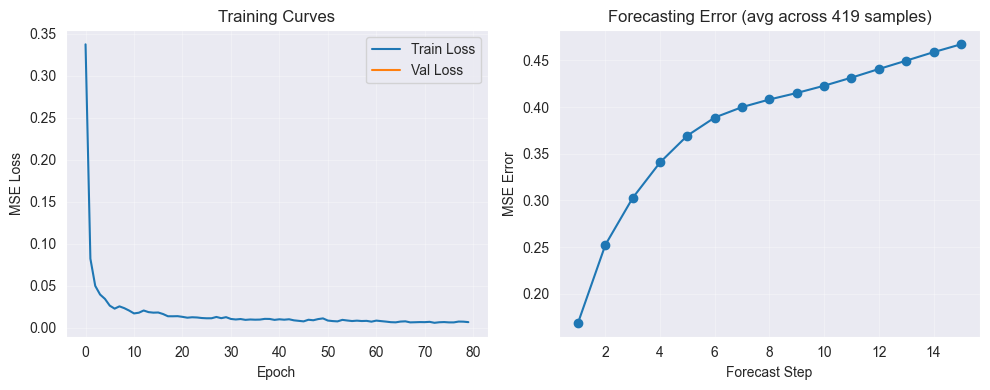

Forecasting errors by step: {1: np.float32(0.16896313), 2: np.float32(0.25244987), 3: np.float32(0.30275333), 4: np.float32(0.3407337), 5: np.float32(0.36944735), 6: np.float32(0.38877344), 7: np.float32(0.39992246), 8: np.float32(0.4080836), 9: np.float32(0.41502878), 10: np.float32(0.42280656), 11: np.float32(0.4314696), 12: np.float32(0.44068426), 13: np.float32(0.44963956), 14: np.float32(0.45873418), 15: np.float32(0.46712354)}


In [39]:
# Plot training curves
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training Curves')
plt.legend()
plt.grid(True, alpha=0.3)

# Evaluate forecasting loss
print("\nEvaluating forecasting performance...")
forecasting_steps = 15
forecast_errors = evaluate_forecasting_loss_fast(
    transformer_model,
    z_train,
    forecasting_steps=forecasting_steps,
    device=device
)

plt.subplot(1, 2, 2)
plt.plot(range(1, forecasting_steps + 1), forecast_errors, marker='o')
plt.xlabel('Forecast Step')
plt.ylabel('MSE Error')
plt.title(f'Forecasting Error (avg across {len(z_train)} samples)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Forecasting errors by step: {dict(zip(range(1, forecasting_steps + 1), forecast_errors))}")

z_train shape: (419, 4)
z_train_next shape: (419, 4)
x_current: (419, 560), x_next: (419, 560)


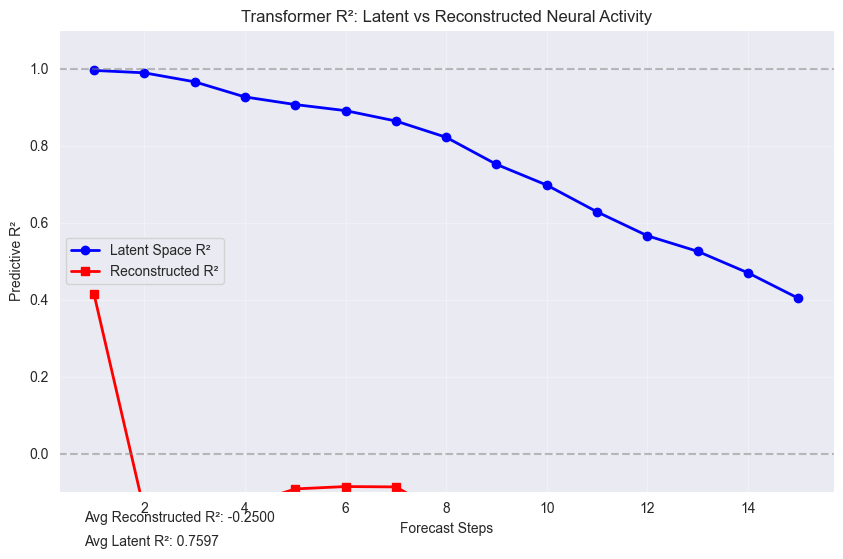


Latent space R²: [0.99503034 0.98882675 0.96551204 0.9261807  0.9063706  0.8905772
 0.8636229  0.82132185 0.7509477  0.6970957  0.627518   0.5654626
 0.52503484 0.46910024 0.40307623]
Reconstructed R²: [ 0.41555738 -0.14812268 -0.18120899 -0.13418212 -0.09199717 -0.08583808
 -0.08674924 -0.16081756 -0.22611125 -0.26187558 -0.39514086 -0.4293401
 -0.58232129 -0.64006363 -0.74196672]

Average Latent R²: 0.7597
Average Reconstructed R²: -0.2500
Reconstruction drop: 1.0097

--- Debugging mode (calling functions separately) ---
x_current: (419, 560), x_next: (419, 560)
Reconstructed R²: [ 0.41555738 -0.14812268 -0.18120899 -0.13418212 -0.09199717 -0.08583808
 -0.08674924 -0.16081756 -0.22611125 -0.26187558 -0.39514086 -0.4293401
 -0.58232129 -0.64006363 -0.74196672]


In [51]:
def plot_r2_comparison(r2_latent, r2_recon, title="R² Comparison: Latent vs Reconstructed"):
    """
    Plot comparison of R² scores in latent and reconstructed spaces.
    """
    plt.figure(figsize=(10, 6))

    steps = range(1, len(r2_latent) + 1)
    plt.plot(steps, r2_latent, marker='o', linewidth=2, color='blue', label='Latent Space R²')
    plt.plot(steps, r2_recon, marker='s', linewidth=2, color='red', label='Reconstructed R²')

    plt.xlabel('Forecast Steps')
    plt.ylabel('Predictive R²')
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
    plt.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    plt.legend()
    plt.ylim(-0.1, 1.1)

    # Add improvement/drop annotation
    avg_latent = np.mean(r2_latent)
    avg_recon = np.mean(r2_recon)
    plt.figtext(0.15, 0.02, f'Avg Latent R²: {avg_latent:.4f}', fontsize=10)
    plt.figtext(0.15, 0.06, f'Avg Reconstructed R²: {avg_recon:.4f}', fontsize=10)

    plt.show()

    return avg_latent, avg_recon

def compute_transformer_r2_latent(transformer_model, z_current, z_next,
                                 num_initial_points=20, max_forecast_steps=15,
                                 device='cuda'):
    """
    Compute R^2 predictive metric for the transformer model in latent space only.

    Args:
        transformer_model: Trained transformer for latent space forecasting
        z_current: Current latent vectors (n_samples, latent_dim)
        z_next: Next latent vectors (n_samples, latent_dim)
        num_initial_points: Number of uniformly spaced starting points
        max_forecast_steps: Maximum forecast steps
        device: Device to run computations on

    Returns:
        r2_scores: Array of R^2 scores for each forecast step
        latent_predictions: Dictionary containing latent predictions
    """
    transformer_model.eval()

    n_samples = len(z_current)

    # Select uniformly spaced starting indices
    indices = np.linspace(0, n_samples - max_forecast_steps - 1,
                         num_initial_points, dtype=int)

    # Pre-compute global mean of latent vectors
    # We can use either z_current or z_next, but let's use z_next since that's what we're predicting
    z_global_mean = np.mean(z_next, axis=0)

    # Dictionary to store predictions
    latent_predictions = {}

    with torch.no_grad():
        for s in range(1, max_forecast_steps + 1):
            total_squared_error = 0
            total_variance = 0

            for t0_idx in indices:
                # Get starting latent vector
                z_start = z_current[t0_idx]

                # Forecast s steps ahead in latent space
                z_forecast = transformer_forecast(
                    z_start, transformer_model, s, device
                )

                # Get the last predicted latent vector (at t0 + s)
                z_pred = z_forecast[-1]  # Shape: (latent_dim,)

                # Get actual latent vector at t0 + s
                # Note: z_next[t0_idx] is z_{t0+1}, so we need to adjust
                z_actual = z_next[t0_idx + s - 1]

                # Store predictions for analysis
                if s not in latent_predictions:
                    latent_predictions[s] = {
                        'predicted': [],
                        'actual': [],
                        't0_indices': []
                    }

                latent_predictions[s]['predicted'].append(z_pred)
                latent_predictions[s]['actual'].append(z_actual)
                latent_predictions[s]['t0_indices'].append(t0_idx)

                # Compute squared error
                squared_error = np.sum((z_pred - z_actual) ** 2)
                total_squared_error += squared_error

                # Compute variance term
                variance_term = np.sum((z_actual - z_global_mean) ** 2)
                total_variance += variance_term

    # Compute R² for each forecast step
    r2_scores = []
    for s in range(1, max_forecast_steps + 1):
        preds = np.array(latent_predictions[s]['predicted'])
        actuals = np.array(latent_predictions[s]['actual'])

        # Check if we have any predictions for this step
        if len(preds) == 0:
            r2_scores.append(0)
            continue

        total_squared_error = np.sum((preds - actuals) ** 2)
        total_variance = np.sum((actuals - z_global_mean) ** 2)

        if total_variance == 0:
            r2 = 0
        else:
            r2 = 1 - (total_squared_error / total_variance)

        r2_scores.append(r2)

    return np.array(r2_scores), latent_predictions


def compute_transformer_r2_reconstructed(transformer_model, autoencoder_model,
                                        x_current, x_next,
                                        num_initial_points=20, max_forecast_steps=15,
                                        window_length=10, n_neurons=56,
                                        device='cuda'):
    """
    Compute R^2 predictive metric in the RECONSTRUCTED neural space.

    Args:
        transformer_model: Trained transformer for latent space forecasting
        autoencoder_model: The full autoencoder model
        x_current: Current neural activity windows (n_samples, window_len * n_neurons) OR (n_samples, window_len, n_neurons)
        x_next: Next neural activity windows (same shape as x_current)
        num_initial_points: Number of uniformly spaced starting points
        max_forecast_steps: Maximum forecast steps
        window_length: Length of each time window
        n_neurons: Number of neurons
        device: Device to run computations on

    Returns:
        r2_scores: Array of R^2 scores for each forecast step
        predictions_dict: Dictionary containing predictions and reconstructions
    """
    transformer_model.eval()
    autoencoder_model.eval()

    print(f'x_current: {x_current.shape}, x_next: {x_next.shape}')

    # Reshape if data is flattened
    if x_current.ndim == 2:
        # Reshape from (n_samples, window_len * n_neurons) to (n_samples, window_len, n_neurons)
        n_samples = x_current.shape[0]
        x_current_3d = x_current.reshape(n_samples, window_length, n_neurons)
        x_next_3d = x_next.reshape(n_samples, window_length, n_neurons)
    else:
        x_current_3d = x_current
        x_next_3d = x_next

    n_samples = len(x_current_3d)

    # Select uniformly spaced starting indices
    indices = np.linspace(0, n_samples - max_forecast_steps - 1,
                         num_initial_points, dtype=int)

    # Pre-compute global mean of neural activity
    # We'll use the first time step of each window for comparison
    x_next_first_step = x_next_3d[:, 0, :]  # Take first time step of each window
    x_global_mean = np.mean(x_next_first_step, axis=0)  # Mean over samples

    # Dictionary to store predictions
    predictions_dict = {}

    with torch.no_grad():
        for s in range(1, max_forecast_steps + 1):
            total_squared_error = 0
            total_variance = 0

            for t0_idx in indices:
                # Get starting neural activity window (flattened for model input)
                if x_current.ndim == 2:
                    x_start = x_current[t0_idx:t0_idx+1]  # Shape: (1, window_len * n_neurons)
                else:
                    x_start = x_current[t0_idx:t0_idx+1].reshape(1, -1)  # Flatten to (1, window_len * n_neurons)

                x_start_tensor = torch.FloatTensor(x_start).to(device)

                # Encode to get starting latent vector
                # Run through the autoencoder's encoder part
                x_proj = autoencoder_model.input_projection(x_start_tensor)
                x_proj = autoencoder_model.pos_encoding(x_proj)
                transformer_out = autoencoder_model.transformer(x_proj)
                pooled = autoencoder_model.pool(transformer_out.transpose(1, 2)).squeeze(2)
                z_start = autoencoder_model.latent_projection(pooled)

                # Forecast s steps ahead in latent space
                z_start_np = z_start.cpu().numpy()[0]
                z_forecast = transformer_forecast(
                    z_start_np, transformer_model, s, device
                )

                # Get the last predicted latent vector (at t0 + s)
                z_pred_np = z_forecast[-1]  # Shape: (latent_dim,)
                z_pred_tensor = torch.FloatTensor(z_pred_np).unsqueeze(0).to(device)

                # Decode to neural space
                x_pred_reconstructed = autoencoder_model.decoder(z_pred_tensor)

                # Get actual neural activity at t0 + s
                # We want the first time step of the window at t0 + s
                actual_window = x_next_3d[t0_idx + s - 1]  # Shape: (window_len, n_neurons)
                x_actual = actual_window[0, :]  # First time step

                # Convert predictions to numpy
                # The decoder outputs (batch, output_dim) where output_dim = window_len * n_neurons
                x_pred_full = x_pred_reconstructed.cpu().numpy()[0]  # Shape: (window_len * n_neurons,)

                # Reshape to get the first time step
                x_pred_reshaped = x_pred_full.reshape(window_length, n_neurons)
                x_pred_np = x_pred_reshaped[0, :]  # First time step

                # Store predictions for analysis
                if s not in predictions_dict:
                    predictions_dict[s] = {
                        'predicted': [],
                        'actual': [],
                        'reconstructed': [],
                        't0_indices': [],
                        'full_window_reconstructed': []
                    }

                predictions_dict[s]['predicted'].append(z_pred_np)
                predictions_dict[s]['actual'].append(x_actual)
                predictions_dict[s]['reconstructed'].append(x_pred_np)
                predictions_dict[s]['full_window_reconstructed'].append(x_pred_full)
                predictions_dict[s]['t0_indices'].append(t0_idx)

                # Compute squared error on RECONSTRUCTED neural activity
                squared_error = np.sum((x_pred_np - x_actual) ** 2)
                total_squared_error += squared_error

                # Compute variance term
                variance_term = np.sum((x_actual - x_global_mean) ** 2)
                total_variance += variance_term

    # Compute R² for each forecast step
    r2_scores = []
    for s in range(1, max_forecast_steps + 1):
        reconstructions = np.array(predictions_dict[s]['reconstructed'])
        actuals = np.array(predictions_dict[s]['actual'])

        if len(reconstructions) == 0:
            r2_scores.append(0)
            continue

        # Compute R² for neural reconstructions
        total_squared_error = np.sum((reconstructions - actuals) ** 2)
        total_variance = np.sum((actuals - x_global_mean) ** 2)

        if total_variance == 0:
            r2 = 0
        else:
            r2 = 1 - (total_squared_error / total_variance)

        r2_scores.append(r2)

    return np.array(r2_scores), predictions_dict


# Updated helper function to handle flattened input
def encode_sequence_flattened(autoencoder_model, x_sequence, device='cuda'):
    """
    Encode a sequence of flattened neural activity windows to latent space.
    x_sequence shape: (n_samples, window_len * n_neurons)
    """
    autoencoder_model.eval()
    latents = []

    with torch.no_grad():
        for i in range(len(x_sequence)):
            x_window = torch.FloatTensor(x_sequence[i:i+1]).to(device)

            # Run through encoder
            x_proj = autoencoder_model.input_projection(x_window)
            x_proj = autoencoder_model.pos_encoding(x_proj)
            transformer_out = autoencoder_model.transformer(x_proj)
            pooled = autoencoder_model.pool(transformer_out.transpose(1, 2)).squeeze(2)
            z = autoencoder_model.latent_projection(pooled)

            latents.append(z.cpu().numpy()[0])

    return np.array(latents)


def compute_transformer_r2_compare_both(transformer_model, autoencoder_model,
                                       x_current, x_next, z_current, z_next,
                                       num_initial_points=20, max_forecast_steps=15,
                                       window_length=10, n_neurons=56,
                                       device='cuda'):
    """
    Compute R² in BOTH latent and reconstructed spaces for comparison.
    """
    # Compute latent R²
    r2_latent, latent_preds = compute_transformer_r2_latent(
        transformer_model, z_current, z_next,
        num_initial_points, max_forecast_steps, device
    )

    # Compute reconstructed R² - ADD THE NEW PARAMETERS!
    r2_recon, recon_preds = compute_transformer_r2_reconstructed(
        transformer_model, autoencoder_model,
        x_current, x_next,
        num_initial_points, max_forecast_steps,
        window_length, n_neurons,  # Add these!
        device
    )

    return {
        'latent_r2': r2_latent,
        'reconstructed_r2': r2_recon,
        'latent_predictions': latent_preds,
        'reconstructed_predictions': recon_preds
    }


# Now call it with all parameters:
#print(f"traj_windows shape: {traj_windows.shape}")
#print(f"traj_next_windows shape: {traj_next_windows.shape}")

# Compute latents using the flattened version
# z_train = encode_sequence_flattened(model, traj_windows, device)
# z_train_next = encode_sequence_flattened(model, traj_next_windows, device)

print(f"z_train shape: {z_train.shape}")
print(f"z_train_next shape: {z_train_next.shape}")

# Compute R² in both spaces - ADD WINDOW_LENGTH AND N_NEURONS!
if True:
    results = compute_transformer_r2_compare_both(
        transformer_model=transformer_model,
        autoencoder_model=model,
        #x_current=traj_windows,  # Flattened: (419, 560)
        #x_next=traj_next_windows,  # Flattened: (419, 560)
        x_current = X_train_scaled_forecast,
        x_next = X_train_next_forecast_scaled,
        z_current=z_train_scaled,
        z_next=z_train_next_scaled,
        num_initial_points=20,
        max_forecast_steps=15,
        window_length=window_size,  # ADD THIS!
        n_neurons=56,      # ADD THIS!
        device=device
    )

# Plot comparison
avg_latent, avg_recon = plot_r2_comparison(
    results['latent_r2'],
    results['reconstructed_r2'],
    title="Transformer R²: Latent vs Reconstructed Neural Activity"
)

print(f"\nLatent space R²: {results['latent_r2']}")
print(f"Reconstructed R²: {results['reconstructed_r2']}")
print(f"\nAverage Latent R²: {avg_latent:.4f}")
print(f"Average Reconstructed R²: {avg_recon:.4f}")
print(f"Reconstruction drop: {avg_latent - avg_recon:.4f}")

#if you prefer to call them separately for debugging:
print("\n--- Debugging mode (calling functions separately) ---")
# Compute latent R²
#r2_latent, latent_preds = compute_transformer_r2_latent(
#    transformer_model, z_train, z_train_next,
#    num_initial_points=20, max_forecast_steps=15, device=device
#)


# Compute reconstructed R²
r2_recon, recon_preds = compute_transformer_r2_reconstructed(
    transformer_model, model,
    #x_current=traj_windows,
    #x_next=traj_next_windows,
    x_current = X_train_scaled_forecast,
    x_next = X_train_next_forecast_scaled,
    num_initial_points=20,
    max_forecast_steps=15,
    window_length=window_size,  # Explicitly set
    n_neurons=56,      # Explicitly set
    device=device
)

# print(f"Latent R²: {r2_latent}")
print(f"Reconstructed R²: {r2_recon}")

In [52]:
r2_recon

array([ 0.41555738, -0.14812268, -0.18120899, -0.13418212, -0.09199717,
       -0.08583808, -0.08674924, -0.16081756, -0.22611125, -0.26187558,
       -0.39514086, -0.4293401 , -0.58232129, -0.64006363, -0.74196672])

In [53]:
results['latent_r2']

array([0.99503034, 0.98882675, 0.96551204, 0.9261807 , 0.9063706 ,
       0.8905772 , 0.8636229 , 0.82132185, 0.7509477 , 0.6970957 ,
       0.627518  , 0.5654626 , 0.52503484, 0.46910024, 0.40307623],
      dtype=float32)

In [62]:
window_size

10

In [63]:
r2_recon_latent4 = [

]

r2_runs_recon_w10_stupid_cluster = [ # this is for pure recon
    [  0.73429761,   0.55104938,   0.21991208,  -0.30258826,
        -0.9856788 ,  -1.90343456,  -3.00564468,  -4.43265124,
        -5.83813954,  -7.15801116,  -8.91408701, -10.74719609,
       -13.40391968, -16.06599396, -19.35816475],
[ 0.77465366,  0.72976785,  0.65360031,  0.54469143,  0.43330936,
        0.28347336,  0.16679844,  0.00864628, -0.13270279, -0.29548016,
       -0.46671729, -0.6450266 , -0.95896349, -1.41854535, -1.72854169],
    [  0.77180241,   0.68293356,   0.51432841,   0.23856865,
        -0.10007077,  -0.61996448,  -1.26362411,  -2.15788637,
        -3.15014383,  -4.28801445,  -5.7118354 ,  -7.23122422,
        -9.38992889, -11.60907138, -13.82452259],
    [ 0.72705446,  0.55955319,  0.38083528,  0.18473812, -0.11241872,
       -0.39708068, -0.73734749, -1.17799223, -1.60669741, -2.15117323,
       -2.841653  , -3.44450637, -4.35206908, -5.09675678, -6.00999535],
    [ 0.73846862,  0.60561585,  0.40762194,  0.14896926, -0.12845617,
       -0.45553062, -0.79805494, -1.21279335, -1.59800251, -1.95178973,
       -2.34769996, -2.68828069, -3.16883664, -3.51121719, -3.82341441],
    [ 0.76684505,  0.65931631,  0.51133567,  0.29753679,  0.06660802,
       -0.15880863, -0.43549061, -0.76480935, -1.11028015, -1.43946996,
       -1.9012635 , -2.27152034, -2.86026821, -3.25657824, -3.73619765],
    [ 7.00726429e-01,  4.44448614e-01,  1.53514715e-02, -6.10148397e-01,
       -1.40579658e+00, -2.51784744e+00, -3.88255655e+00, -5.58377045e+00,
       -7.24236934e+00, -8.86735741e+00, -1.08350907e+01, -1.27180273e+01,
       -1.53061729e+01, -1.75477657e+01, -1.96638008e+01],
    [  0.71663202,   0.51944493,   0.22172884,  -0.16829108,
        -0.61763374,  -1.21830586,  -1.87506305,  -2.73843519,
        -3.59437361,  -4.45358074,  -5.48579679,  -6.4745493 ,
        -7.86770657,  -9.17305179, -10.29994487],
    [ 0.7479893 ,  0.59283392,  0.39342445,  0.14635694, -0.14019814,
       -0.45966031, -0.84956936, -1.32642328, -1.82323605, -2.35629773,
       -3.07798231, -3.67954223, -4.62358946, -5.38339152, -6.25263026],
    [  0.76560127,   0.63182009,   0.35546474,  -0.13281981,
        -0.85047495,  -1.88981543,  -3.20387186,  -4.91873483,
        -6.62894325,  -8.30516288, -10.37260719, -12.37965967,
       -15.24937852, -17.72661988, -20.07247824]
]

r2_runs_recon_w10 = [ # this is for \alpha=0.0 and \beta=0.0 (soft prototypes + recon)
    [0.83123122, 0.80850081, 0.79746328, 0.78126168, 0.76092431,
       0.72908656, 0.73632903, 0.7404902 , 0.70830957, 0.66436888,
       0.64345381, 0.61913173, 0.58085007, 0.50048586, 0.44345668],
    [0.82581777, 0.8033579 , 0.79920542, 0.77992508, 0.75249506,
       0.72591298, 0.73584174, 0.73044227, 0.6930363 , 0.65533752,
       0.63964252, 0.63115387, 0.59827214, 0.50399096, 0.44582251],
    [0.83565862, 0.81153503, 0.80327078, 0.79760303, 0.76888337,
       0.73908623, 0.75044901, 0.72945363, 0.69363254, 0.62302162,
       0.61208681, 0.59475007, 0.54868544, 0.45788264, 0.39275238],
    [0.82582922, 0.79847321, 0.79331622, 0.77571066, 0.74390334,
       0.70832837, 0.71089123, 0.6690661 , 0.60833034, 0.52904825,
       0.48895848, 0.45553262, 0.39459501, 0.31013688, 0.25185988],
    [0.81893986, 0.79797113, 0.80039375, 0.77816141, 0.75970729,
       0.72403121, 0.7317529 , 0.71298856, 0.66512874, 0.612639  ,
       0.59076602, 0.56963367, 0.51814871, 0.45597574, 0.41787281],
    [0.83606284, 0.80633882, 0.79902104, 0.77704814, 0.7540274 ,
       0.7213718 , 0.72351108, 0.69806168, 0.65381606, 0.59814479,
       0.58707995, 0.56856193, 0.52420793, 0.46232474, 0.40875005],
    [0.82504668, 0.79899751, 0.79412871, 0.76878847, 0.73688467,
       0.70306556, 0.70293682, 0.69611286, 0.65407742, 0.60538127,
       0.56408992, 0.53697136, 0.49481117, 0.40771681, 0.35258715],
    [0.8228704 , 0.79529903, 0.78038667, 0.74690955, 0.70439938,
       0.65123129, 0.64272597, 0.59375939, 0.53183696, 0.47423513,
       0.44129101, 0.41685388, 0.37374017, 0.27355077, 0.21805739],
    [0.8279022 , 0.81731639, 0.79431357, 0.76092673, 0.72396475,
       0.6847929 , 0.66262367, 0.62500259, 0.56337612, 0.48015768,
       0.44722768, 0.41482871, 0.35348593, 0.27174979, 0.20025424],
    [0.83066588, 0.80200615, 0.79012957, 0.75790948, 0.727518  ,
       0.68119472, 0.67735564, 0.64413501, 0.59708093, 0.56178998,
       0.55329863, 0.54281789, 0.50035371, 0.42042247, 0.36336497]
]

r2_runs_w1 = [
[0.72788545, 0.71890584, 0.69423612, 0.68743778, 0.66304242,
       0.65515312, 0.67265791, 0.68573565, 0.66765833, 0.64081547,
       0.62796862, 0.60085382, 0.56225914, 0.4196808 , 0.35722018],
[0.7388865 , 0.73547985, 0.71307311, 0.7050075 , 0.67805843,
       0.67760265, 0.68626537, 0.6826945 , 0.65262945, 0.62094221,
       0.57535088, 0.52357303, 0.47621486, 0.36191594, 0.30841313],
[0.73528754, 0.73598865, 0.71157539, 0.70629382, 0.67803629,
       0.68223314, 0.6940262 , 0.70204387, 0.6808094 , 0.65628532,
       0.62995711, 0.59102416, 0.54861878, 0.40786909, 0.32709934],
[0.72717341, 0.71742087, 0.6889435 , 0.67760306, 0.64926898,
       0.62990261, 0.6296505 , 0.61748629, 0.57130194, 0.53209928,
       0.50787008, 0.47390439, 0.4376582 , 0.31414922, 0.26940484],
[0.72757354, 0.71534669, 0.69015695, 0.68227485, 0.66051592,
       0.64848633, 0.64892865, 0.64279929, 0.60647633, 0.56983833,
       0.55013895, 0.50048929, 0.4629563 , 0.34729706, 0.28522384],
[0.7274318 , 0.73024044, 0.70470254, 0.69753077, 0.6704055 ,
       0.66724868, 0.67217962, 0.66649431, 0.62927584, 0.5996581 ,
       0.57583932, 0.54251438, 0.51232283, 0.3848381 , 0.33619531],
[0.73720698, 0.73606524, 0.71461798, 0.70883524, 0.68299511,
       0.6848653 , 0.69371413, 0.70394351, 0.68431559, 0.65517227,
       0.64718538, 0.61471399, 0.59766039, 0.48056022, 0.43225756],
[0.73494011, 0.73233449, 0.71093864, 0.7064177 , 0.68326018,
       0.67460573, 0.68458722, 0.6917306 , 0.66770436, 0.64371007,
       0.63542576, 0.6089664 , 0.58199061, 0.45911714, 0.41259239],
[0.73607785, 0.74176301, 0.7238061 , 0.72230615, 0.69731376,
       0.69667165, 0.70532952, 0.715552  , 0.68997641, 0.6668168 ,
       0.64869035, 0.62201903, 0.61150733, 0.50019593, 0.45169742],
[0.7335015 , 0.72572389, 0.70264275, 0.69822152, 0.67691879,
       0.66963624, 0.67458164, 0.67090944, 0.63638038, 0.60340688,
       0.58209695, 0.53945138, 0.50789939, 0.38826743, 0.32905546],
]

# W1 seems to make a bigger collapse
r2_runs_latent_w1 = [
    [0.9940441 , 0.96225786, 0.9466912 , 0.8995543 , 0.8678825 ,
       0.8342321 , 0.78938925, 0.7562625 , 0.69451654, 0.65164804,
       0.50450194, 0.37847573, 0.22295505, 0.19538254, 0.04727632],
    [0.9948512 , 0.9659425 , 0.95330644, 0.91382587, 0.8896711 ,
       0.8788735 , 0.86961246, 0.8685881 , 0.84460515, 0.8134151 ,
       0.71499956, 0.6073369 , 0.49082863, 0.4732741 , 0.35751098],
    [0.9959014 , 0.9662647 , 0.955644  , 0.9133266 , 0.88841033,
       0.8784731 , 0.8669696 , 0.8610965 , 0.81989324, 0.7721983 ,
       0.63760495, 0.50239706, 0.37351   , 0.36728787, 0.24179804],
    [0.9961767 , 0.9681247 , 0.95777214, 0.91881   , 0.8982749 ,
       0.89176553, 0.8833722 , 0.88061893, 0.8402012 , 0.8027441 ,
       0.6801504 , 0.5690625 , 0.44567293, 0.4428469 , 0.31549346],
[0.9943747 , 0.9640609 , 0.9520468 , 0.90853965, 0.88212097,
       0.8693207 , 0.8574072 , 0.85170066, 0.81510985, 0.77475363,
       0.65791917, 0.5492745 , 0.43342805, 0.42848688, 0.31181514]
]

In [64]:
def compute_transformer_r2_compare_both_simple(transformer_model, autoencoder_model,
                                              x_current, x_next, z_current, z_next,
                                              num_initial_points=20, max_forecast_steps=15,
                                              device='cuda'):
    """
    Compute R² in BOTH latent and reconstructed spaces for comparison.
    Automatically infers window_length and n_neurons from data shape.
    """
    # Infer parameters from data shape
    if x_current.ndim == 2:
        # Flattened: (n_samples, window_len * n_neurons)
        # We need to know either window_length or n_neurons to infer the other
        # Since we know n_neurons=56 from the dataset
        n_neurons = 56
        window_length = x_current.shape[1] // n_neurons
        print(f"Inferred: window_length={window_length}, n_neurons={n_neurons}")
    else:
        # 3D: (n_samples, window_length, n_neurons)
        window_length = x_current.shape[1]
        n_neurons = x_current.shape[2]
        print(f"Inferred: window_length={window_length}, n_neurons={n_neurons}")

    # Compute latent R²
    r2_latent, latent_preds = compute_transformer_r2_latent(
        transformer_model, z_current, z_next,
        num_initial_points, max_forecast_steps, device
    )

    # Compute reconstructed R²
    r2_recon, recon_preds = compute_transformer_r2_reconstructed(
        transformer_model, autoencoder_model,
        x_current, x_next,
        num_initial_points, max_forecast_steps,
        window_length, n_neurons,
        device
    )

    return {
        'latent_r2': r2_latent,
        'reconstructed_r2': r2_recon,
        'latent_predictions': latent_preds,
        'reconstructed_predictions': recon_preds,
        'inferred_params': {'window_length': window_length, 'n_neurons': n_neurons}
    }


# Simple call without specifying window_length/n_neurons
results = compute_transformer_r2_compare_both_simple(
    transformer_model=transformer_model,
    autoencoder_model=model,
    x_current=traj_windows,
    x_next=traj_next_windows,
    z_current=z_train,
    z_next=z_train_next,
    num_initial_points=20,
    max_forecast_steps=15,
    device=device
)

Inferred: window_length=10, n_neurons=56
x_current: (4190, 560), x_next: (4190, 560)


Note: maybe do not change original backbone, but only apply discretization on the downstream model.

In [21]:
results['reconstructed_r2']

NameError: name 'results' is not defined

In [30]:
# we don't have the exact data used in the paper, so we try to reproduce it here.
vino_sing_guessed = [0.57, 0.58, 0.56, 0.532, 0.537, 0.531, 0.545, 0.549, 0.54, 0.564, 0.548, 0.52, 0.51, 0.525, 0.53]
vdp_gp=[0.55499775, 0.54690724, 0.52321088, 0.49595883, 0.49060262,
       0.47786709, 0.48716461, 0.4815932 , 0.45930518, 0.476095  ,
       0.45471338, 0.42946475, 0.4036182 , 0.41373812, 0.41807223]
vdp_gp_std = [0.00065783, 0.00115862, 0.00336637, 0.00408811, 0.00560015,
       0.00790103, 0.00930848, 0.01238438, 0.01065142, 0.00979101,
       0.0104968 , 0.01028869, 0.01301124, 0.01976377, 0.02715481]

vino_sing_real = [0.57074404, 0.57578472, 0.55868792, 0.52761798, 0.53054168,
       0.52509842, 0.54626221, 0.54918616, 0.53424408, 0.56366229,
       0.54246488, 0.51927665, 0.5119879 , 0.52103831, 0.5277654 ]
vino_sing_std_real = [7.57042702e-05, 4.07003373e-04, 7.24558985e-04, 1.11878276e-03,
       1.22853470e-03, 1.89823652e-03, 2.61581048e-03, 3.55091488e-03,
       2.27964483e-03, 2.73964008e-03, 3.37890437e-03, 3.88309928e-03,
       5.33802380e-03, 3.51135946e-03, 3.66953175e-03]

# best train run
r2_recon_best_old = [0.70911922, 0.70775977, 0.68613314, 0.67004589, 0.62126063,
       0.59320017, 0.59257684, 0.55707165, 0.54405177, 0.5249343 ,
       0.52961183, 0.51747605, 0.50986278, 0.41852522, 0.41761866]
r2_recon_best = [0.71512837, 0.69474848, 0.673976  , 0.65770755, 0.64222332,
       0.62869301, 0.61605591, 0.60338987, 0.59215246, 0.58253349,
       0.57368135, 0.56298987, 0.55094577, 0.53556116, 0.51906944] # with correct discretization

# runs to get std
r2_runs_w10 = [
    [0.74556032, 0.71655068, 0.71376375, 0.69908999, 0.67691079, 0.65858268,
 0.66681686, 0.65792582, 0.63234416, 0.56772296, 0.54364174, 0.51744257,
 0.48163902, 0.36243387, 0.28307767],
    [0.74556032, 0.71655068, 0.71376375, 0.69908999, 0.67691079,
       0.65858268, 0.66681686, 0.65792582, 0.63234416, 0.56772296,
       0.54364174, 0.51744257, 0.48163902, 0.36243387, 0.28307767],
    [0.74210493, 0.7091876 , 0.7029279 , 0.68252106, 0.65799032,
       0.64128209, 0.65643215, 0.64484949, 0.62568377, 0.58058464,
       0.58700928, 0.57869113, 0.55573681, 0.47991504, 0.44459555],
[0.75166072, 0.73065436, 0.73508785, 0.72219855, 0.69942985,
       0.68670844, 0.69721671, 0.6848818 , 0.67207489, 0.6366336 ,
       0.63313345, 0.62609337, 0.61761617, 0.5814784 , 0.55008504],
[0.74413567, 0.71909431, 0.72393852, 0.71016476, 0.69469034,
       0.68112419, 0.69852209, 0.6932418 , 0.68442025, 0.64673363,
       0.62981223, 0.62076774, 0.60262932, 0.52731334, 0.46499478],
[0.74183036, 0.71434166, 0.71328758, 0.69575613, 0.67655578,
       0.66303862, 0.68352158, 0.68023183, 0.67420448, 0.63953986,
       0.63075176, 0.61818755, 0.59338214, 0.51461541, 0.46131405],
[0.74935366, 0.73051268, 0.73454205, 0.72166343, 0.70988889,
       0.6930709 , 0.70423549, 0.70411326, 0.67613416, 0.62492402,
       0.59936529, 0.57826899, 0.54162518, 0.47217058, 0.4154478 ],
    [0.73979474, 0.71097345, 0.71342712, 0.6979851 , 0.67951662,
       0.65735179, 0.67253351, 0.66755353, 0.65219674, 0.60969875,
       0.58312499, 0.56463307, 0.537306  , 0.44247651, 0.36484863],
    r2_recon_best_old, r2_recon_best
]

r2_runs = np.array(r2_runs_w10)
r2_runs_mean = np.mean(r2_runs, axis=0)
# Compute the entry-wise RMSE for each timestep
rmse_entrywise = np.sqrt(np.mean((r2_runs - r2_runs_mean) ** 2, axis=0))
print("Entry-wise RMSE:", rmse_entrywise)

print(max(rmse_entrywise))

#r2_recon # = results['reconstructed_r2']

Entry-wise RMSE: [0.0136295  0.01010068 0.01839153 0.01972028 0.02542059 0.02814078
 0.03437919 0.04235007 0.04174117 0.03764205 0.03639732 0.04068251
 0.04513319 0.06975046 0.08463746]
0.0846374647114081


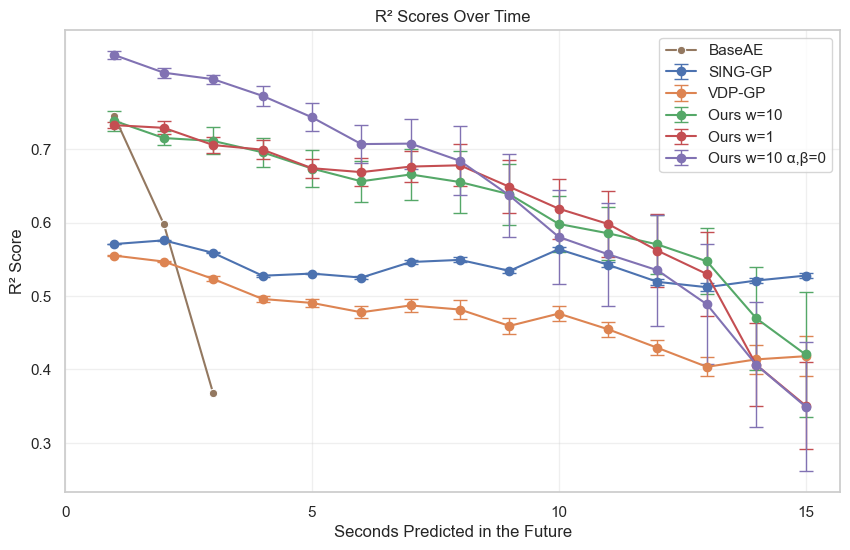

In [31]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Calculate mean and std for r2_runs
r2_runs_mean_w10 = np.mean(r2_runs_w10, axis=0)
r2_runs_std_w10 = np.std(r2_runs_w10, axis=0)

r2_runs_mean_w1 = np.mean(r2_runs_w1, axis=0)
r2_runs_std_w1 = np.std(r2_runs_w1, axis=0)

r2_runs_mean_w10_recon = np.mean(r2_runs_recon_w10, axis=0)
r2_runs_std_w10_recon = np.std(r2_runs_recon_w10, axis=0)

r2_runs_mean_w10_stupid = np.mean(r2_runs_recon_w10_stupid_cluster, axis=0)
r2_runs_std_w10_stupid = np.std(r2_runs_recon_w10_stupid_cluster, axis=0)

# Create a time axis
time_seconds = np.arange(1, len(vino_sing_guessed) + 1)

# Plot using seaborn
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))

# Plot lines
#sns.lineplot(x=time_seconds, y=vino_sing_guessed, label="SING-GP", marker='o')
plt.errorbar(x=time_seconds, y=vino_sing_real, yerr=vino_sing_std_real, fmt='o-', capsize=5, elinewidth=1, capthick=1, label="SING-GP")
#sns.lineplot(x=time_seconds, y=vdp_gp_guessed, label="VDP-GP", marker='o')
#sns.lineplot(x=time_seconds, y=r2_recon_best, label="Ours (best)", marker='o')

# Plot vdp_gp_guessed with error bars
plt.errorbar(x=time_seconds, y=vdp_gp, yerr=vdp_gp_std, fmt='o-', capsize=5, elinewidth=1, capthick=1, label="VDP-GP")

# Plot r2_runs_mean with shaded std
plt.errorbar(time_seconds, y=r2_runs_mean_w10, yerr=r2_runs_std_w10, fmt='o-', capsize=5, elinewidth=1, capthick=1,  label="Ours w=10")
plt.errorbar(time_seconds, y=r2_runs_mean_w1, yerr=r2_runs_std_w1, fmt='o-', capsize=5, elinewidth=1, capthick=1,  label="Ours w=1")
plt.errorbar(time_seconds, y=r2_runs_mean_w10_recon, yerr=r2_runs_std_w10_recon, fmt='o-', capsize=5, elinewidth=1, capthick=1,  label="Ours w=10 α,β=0")
#plt.errorbar(time_seconds[:4], y=r2_runs_mean_w10_stupid[:4], yerr=r2_runs_std_w10_stupid[:4], fmt='o-', capsize=5, elinewidth=1, capthick=1,  label="AE w=10 Recon")
sns.lineplot(x=time_seconds[:3], y=r2_runs_mean_w10_stupid[:3], label="BaseAE", marker='o')


# Customize x-axis ticks and grid lines
plt.xticks(np.arange(0, max(time_seconds) + 1, 5))
plt.grid(axis='x', which='both', alpha=0.3)

# Customize y-axis ticks and grid lines
plt.yticks(np.arange(0.3, 0.7 + 0.1, 0.1))
plt.grid(axis='y', which='both', alpha=0.3)

# Add labels and title
plt.xlabel("Seconds Predicted in the Future")
plt.ylabel("R² Score")
plt.title("R² Scores Over Time")
plt.legend()

# Show plot
plt.show()

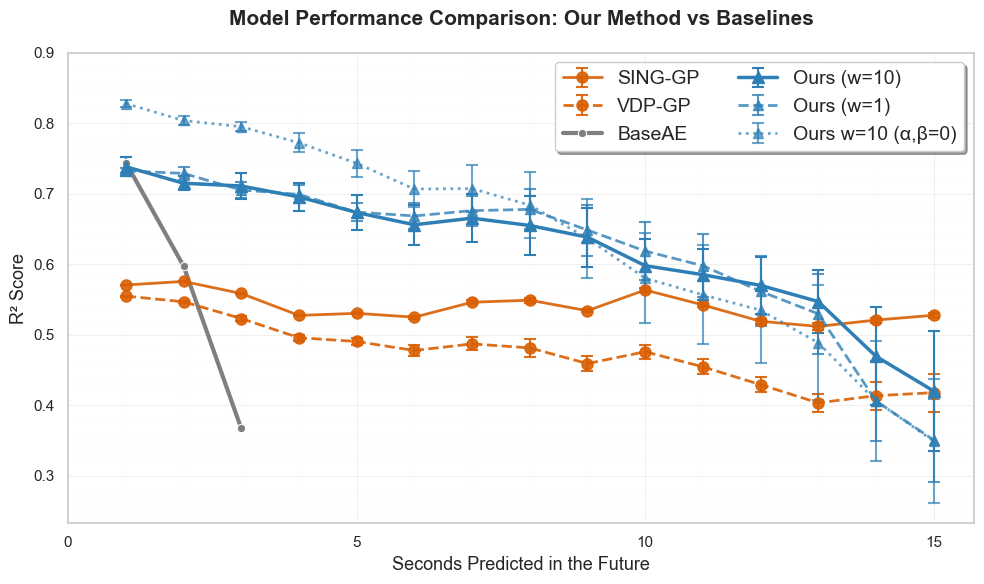

In [32]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Calculate mean and std for r2_runs
r2_runs_mean_w10 = np.mean(r2_runs_w10, axis=0)
r2_runs_std_w10 = np.std(r2_runs_w10, axis=0)

r2_runs_mean_w1 = np.mean(r2_runs_w1, axis=0)
r2_runs_std_w1 = np.std(r2_runs_w1, axis=0)

r2_runs_mean_w10_recon = np.mean(r2_runs_recon_w10, axis=0)
r2_runs_std_w10_recon = np.std(r2_runs_recon_w10, axis=0)

r2_runs_mean_w10_stupid = np.mean(r2_runs_recon_w10_stupid_cluster, axis=0)
r2_runs_std_w10_stupid = np.std(r2_runs_recon_w10_stupid_cluster, axis=0)

# Create a time axis
time_seconds = np.arange(1, len(vino_sing_guessed) + 1)

# Define "us vs them" color palette
our_color = '#2E7FB5'  # Consistent blue for our methods
baseline_color = '#D95F02'  # Distinct orange for baselines
reduced_alpha = '#7F7F7F'  # Gray for less important variants

# Set style
sns.set_style("whitegrid")
plt.figure(figsize=(10, 6))

# ===== BASELINES (Circles) =====
# Plot SING-GP (baseline) - use circles
#ns.lineplot(x=time_seconds, y=vino_sing_guessed,
#             label="SING-GP",
#             marker='o', markersize=8, linewidth=2,
#             color=baseline_color)

# Plot SING with error bars (baseline)
plt.errorbar(x=time_seconds, y=vino_sing_real, yerr=vino_sing_std_real,
             fmt='o-', capsize=4, elinewidth=1.5, capthick=1.5,
             markersize=8, linewidth=2,
             color=baseline_color, alpha=0.9,
             label="SING-GP")

# Plot VDP-GP with error bars (baseline)
plt.errorbar(x=time_seconds, y=vdp_gp, yerr=vdp_gp_std,
             fmt='o--', capsize=4, elinewidth=1.5, capthick=1.5,
             markersize=8, linewidth=2,
             color=baseline_color, alpha=0.9,
             label="VDP-GP")

# ===== OUR METHODS (Triangles) =====
# Main variant - solid triangle line
plt.errorbar(time_seconds, y=r2_runs_mean_w10, yerr=r2_runs_std_w10,
             fmt='^-', capsize=4, elinewidth=1.5, capthick=1.5,
             markersize=9, linewidth=2.5,
             color=our_color, alpha=1.0,
             label="Ours (w=10)")

# Other variants - different line styles with triangles
plt.errorbar(time_seconds, y=r2_runs_mean_w1, yerr=r2_runs_std_w1,
             fmt='^--', capsize=4, elinewidth=1.5, capthick=1.5,
             markersize=7, linewidth=2,
             color=our_color, alpha=0.8,
             label="Ours (w=1)")

plt.errorbar(time_seconds, y=r2_runs_mean_w10_recon, yerr=r2_runs_std_w10_recon,
             fmt='^:', capsize=4, elinewidth=1.5, capthick=1.5,
             markersize=7, linewidth=2,
             color=our_color, alpha=0.7,
             label="Ours w=10 (α,β=0)")

# BaseAE - special case, dashed gray line
#plt.errorbar(time_seconds[:3], y=r2_runs_mean_w10_stupid[:3],
#             yerr=r2_runs_std_w10_stupid[:3] if len(r2_runs_std_w10_stupid) >= 3 else 0,
#             fmt='s--', capsize=4, elinewidth=1.5, capthick=1.5,
#             markersize=7, linewidth=1.5,
#             color=reduced_alpha, alpha=0.7,
#             label="BaseAE")
sns.lineplot(x=time_seconds[:3], y=r2_runs_mean_w10_stupid[:3], label="BaseAE", marker='o', color=reduced_alpha, linewidth=3)


# Customize x-axis
# Customize x-axis ticks and grid lines
plt.xticks(np.arange(0, max(time_seconds) + 1, 5))
plt.grid(axis='x', which='both', alpha=0.3)

# Customize y-axis ticks and grid lines
plt.yticks(np.arange(0.3, 0.8 + 0.1, 0.1))
plt.grid(axis='y', which='both', alpha=0.3)

# Grid customization
plt.grid(axis='both', which='major', alpha=0.4, linestyle='-', linewidth=0.5)
plt.grid(axis='both', which='minor', alpha=0.2, linestyle=':', linewidth=0.3)
plt.minorticks_on()

# Labels and title with improved formatting
plt.xlabel("Seconds Predicted in the Future", fontsize=13, fontweight='medium')
plt.ylabel("R² Score", fontsize=13, fontweight='medium')
plt.title("Model Performance Comparison: Our Method vs Baselines",
          fontsize=15, fontweight='bold', pad=20)

# Improved legend - group by "us vs them"
# Get all legend handles and labels
handles, labels = plt.gca().get_legend_handles_labels()

# Create a mapping to reorder items
label_order = ["SING-GP", "VDP-GP", "BaseAE", "Ours (w=10)", "Ours (w=1)", "Ours w=10 (α,β=0)"]

# Create a dictionary to map labels to their handles
label_to_handle = dict(zip(labels, handles))

# Reorder handles and labels according to our desired order
ordered_handles = []
ordered_labels = []

for label in label_order:
    if label in label_to_handle:
        ordered_handles.append(label_to_handle[label])
        ordered_labels.append(label)

# Create the legend with the ordered items
plt.legend(handles=ordered_handles, labels=ordered_labels,
           loc='upper right',
           ncol=2,
           frameon=True,
           fancybox=True,
           shadow=True,
           fontsize=14)

plt.tight_layout()
plt.show()

In [8]:
import numpy as np

data = np.load('sing_fig6e_left_results.npz')

# List all available array names
print(data.files)


['mean_r2s_sing', 'stderr_r2s_sing', 'mean_r2s_vdp', 'stderr_r2s_vdp']


In [10]:
for key in data.files:
    print(f"{key}")#: {data.files[key]}")

mean_r2s_sing
stderr_r2s_sing
mean_r2s_vdp
stderr_r2s_vdp


In [29]:
data['stderr_r2s_vdp']

array([0.00065783, 0.00115862, 0.00336637, 0.00408811, 0.00560015,
       0.00790103, 0.00930848, 0.01238438, 0.01065142, 0.00979101,
       0.0104968 , 0.01028869, 0.01301124, 0.01976377, 0.02715481])